# Quantum Oracles, Deutsch-Jozsa, and Grover

**Motivating question:** What does it really mean to solve a problem by querying an oracle, and why can that change the apparent cost of a computation?

**Learning goals**
- explain classical black-box functions and why query complexity is a special cost model
- visualize how a classical Boolean function is embedded into a reversible and then quantum oracle
- distinguish bit-flip and phase oracles before using them inside algorithms
- build the conceptual bridge needed for later sections on Deutsch-Jozsa and Grover
- keep oracle construction cost visible instead of treating it as magic

**Notebook roadmap**
1. Why oracles matter
2. Visual oracle intuition
3. Deutsch's problem as a warm-up
4. Deutsch-Jozsa theory
5. Deutsch-Jozsa in Qiskit
6. Grover theory
7. Grover in Qiskit
8. Assessment framework for oracle-based algorithms
9. Comparative analysis: what the speedup claim really means
10. Summary and further exercises

*Sections 0-7 are implemented in this version. The later assessment and synthesis sections come next.*


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import Rectangle

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from utilities.complexity_utils import (
    COLORS,
    display_wrapped,
    instructor_prompt,
    markdown_box,
    plot_grouped_bars,
    setup_lecture_style,
)

setup_lecture_style()
np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = lambda value: f'{value:,.3g}'


In [2]:
def bitstrings(n):
    return [format(index, f'0{n}b') for index in range(2 ** n)]


def plot_query_model_contrast(*, title='Query complexity isolates oracle calls; runtime must count more'):
    fig, ax = plt.subplots(figsize=(12.8, 5.0), constrained_layout=True)
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 5.7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    def box(x, y, w, h, text, *, facecolor):
        rect = Rectangle((x, y), w, h, facecolor=facecolor, edgecolor=COLORS['gray'], linewidth=1.3)
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=11)

    ax.text(0.45, 4.95, 'Query model', fontsize=16, color=COLORS['navy'], fontweight='semibold')
    box(0.45, 3.55, 2.1, 0.9, 'choose query x', facecolor='#e7eef6')
    box(3.05, 3.55, 3.1, 0.9, 'oracle O_f returns f(x)', facecolor='#d9e8ea')
    box(6.7, 3.55, 2.5, 0.9, 'update algorithm state', facecolor='#eef4eb')
    box(9.75, 3.55, 2.2, 0.9, 'query count += 1', facecolor='#f3ece8')

    for x0, x1 in [(2.55, 3.05), (6.15, 6.7), (9.2, 9.75)]:
        ax.annotate('', xy=(x1, 4.0), xytext=(x0, 4.0), arrowprops={'arrowstyle': '->', 'linewidth': 1.7, 'color': COLORS['gray']})

    ax.text(0.45, 2.1, 'End-to-end execution', fontsize=16, color=COLORS['rust'], fontweight='semibold')
    box(0.45, 0.7, 2.2, 0.9, 'specify problem instance', facecolor='#f6efe9')
    box(3.0, 0.7, 2.5, 0.9, 'build or compile oracle', facecolor='#f6d9cc')
    box(5.85, 0.7, 2.15, 0.9, 'run query steps', facecolor='#f6c6b1')
    box(8.35, 0.7, 2.0, 0.9, 'measure / decode', facecolor='#f6d9cc')
    box(10.7, 0.7, 1.85, 0.9, 'interpret answer', facecolor='#f6efe9')

    for x0, x1 in [(2.65, 3.0), (5.5, 5.85), (8.0, 8.35), (10.35, 10.7)]:
        ax.annotate('', xy=(x1, 1.15), xytext=(x0, 1.15), arrowprops={'arrowstyle': '->', 'linewidth': 1.7, 'color': COLORS['gray']})

    ax.text(6.5, 5.2, 'Useful abstraction: count only how many times O_f is queried', ha='center', color=COLORS['navy'], fontsize=11)
    ax.text(6.5, 2.35, 'Necessary caveat: fewer queries do not automatically mean smaller total runtime', ha='center', color=COLORS['rust'], fontsize=11)
    ax.set_title(title, loc='left')
    return fig, ax


def plot_truth_table_gallery(function_specs, *, title='Small Boolean functions as truth tables'):
    rows = int(np.ceil(len(function_specs) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(12.5, 3.0 * rows + 0.6), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, (name, mapping, note) in zip(axes, function_specs):
        ax.axis('off')
        cell_text = [[x, mapping[x]] for x in sorted(mapping)]
        table = ax.table(
            cellText=cell_text,
            colLabels=['x', 'f(x)'],
            cellLoc='center',
            colColours=['#d9e8ea', '#eef4eb'],
            loc='center',
        )
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.2, 1.5)
        ax.set_title(name, loc='left', fontsize=14, color=COLORS['navy'])
        ax.text(0.0, 0.08, note, transform=ax.transAxes, fontsize=10.5, color=COLORS['gray'])

    for ax in axes[len(function_specs):]:
        ax.axis('off')

    fig.suptitle(title, x=0.06, ha='left', fontsize=18, fontweight='semibold')
    return fig, axes


def plot_reversible_embedding(mapping, *, title='Reversible embedding: preserve x, update y'):
    fig, ax = plt.subplots(figsize=(12.5, 5.8), constrained_layout=True)
    ax.set_xlim(0, 12.5)
    ax.set_ylim(0, 6.6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(1.3, 5.95, 'Input basis states', fontsize=15, color=COLORS['navy'], fontweight='semibold')
    ax.text(8.2, 5.95, 'Output basis states', fontsize=15, color=COLORS['teal'], fontweight='semibold')
    ax.text(0.7, 5.3, r'$U_f\,|x, y\rangle = |x, y \oplus f(x)\rangle$', fontsize=14)

    ordered_inputs = [('0', 0), ('0', 1), ('1', 0), ('1', 1)]
    y_positions = [4.6, 3.5, 2.4, 1.3]
    colors = {'0': '#d9e8ea', '1': '#f6d9cc'}

    for (x, y), y_pos in zip(ordered_inputs, y_positions):
        output_y = y ^ mapping[x]
        left_text = rf'$|{x}, {y}\rangle$'
        right_text = rf'$|{x}, {output_y}\rangle$'
        left_box = Rectangle((0.8, y_pos - 0.33), 2.3, 0.66, facecolor=colors[x], edgecolor=COLORS['gray'], linewidth=1.2)
        right_box = Rectangle((8.2, y_pos - 0.33), 2.5, 0.66, facecolor=colors[x], edgecolor=COLORS['gray'], linewidth=1.2)
        ax.add_patch(left_box)
        ax.add_patch(right_box)
        ax.text(1.95, y_pos, left_text, ha='center', va='center', fontsize=13)
        ax.text(9.45, y_pos, right_text, ha='center', va='center', fontsize=13)
        ax.annotate('', xy=(8.1, y_pos), xytext=(3.25, y_pos), arrowprops={'arrowstyle': '->', 'linewidth': 1.8, 'color': COLORS['gray']})

    ax.text(4.3, 5.35, 'The extra target bit y stores the answer without erasing x.', fontsize=11, color=COLORS['gray'])
    ax.text(4.3, 0.62, 'Because every basis state maps to a unique basis state, the transformation is reversible.', fontsize=11, color=COLORS['gray'])
    ax.set_title(title, loc='left')
    return fig, ax


def plot_bitflip_and_phase_oracles(mapping, *, title='Bit-flip and phase oracles package the same function differently'):
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), constrained_layout=True)

    left_ax = axes[0]
    left_ax.set_xlim(0, 10)
    left_ax.set_ylim(0, 5)
    left_ax.set_xticks([])
    left_ax.set_yticks([])
    left_ax.grid(False)
    for spine in left_ax.spines.values():
        spine.set_visible(False)

    left_ax.set_title('Bit-flip oracle', loc='left')
    left_ax.text(0.2, 4.35, r'$U_f\,|x, y\rangle = |x, y \oplus f(x)\rangle$', fontsize=13)
    transitions = []
    for x in ['0', '1']:
        for y in [0, 1]:
            transitions.append((rf'$|{x}, {y}\rangle$', rf'$|{x}, {y ^ mapping[x]}\rangle$'))

    for row, (left_state, right_state) in enumerate(transitions):
        y_pos = 3.45 - 0.78 * row
        left_ax.text(0.5, y_pos, left_state, fontsize=12)
        left_ax.annotate('', xy=(6.5, y_pos), xytext=(2.6, y_pos), arrowprops={'arrowstyle': '->', 'linewidth': 1.5, 'color': COLORS['gray']})
        left_ax.text(6.9, y_pos, right_state, fontsize=12)

    right_ax = axes[1]
    labels = [r'$|0\rangle$', r'$|1\rangle$']
    values = [1 if mapping['0'] == 0 else -1, 1 if mapping['1'] == 0 else -1]
    colors = [COLORS['teal'] if value > 0 else COLORS['rust'] for value in values]
    right_ax.bar(labels, values, color=colors)
    right_ax.axhline(0, color=COLORS['gray'], linewidth=1.2)
    right_ax.set_ylim(-1.3, 1.3)
    right_ax.set_ylabel('Relative sign on amplitude')
    right_ax.set_title('Phase oracle', loc='left')
    right_ax.text(-0.45, 1.08, r'$S_f\,|x\rangle = (-1)^{f(x)} |x\rangle$', fontsize=13)
    right_ax.text(-0.35, -1.18, 'Marked inputs keep the same basis label but acquire a negative phase.', fontsize=10.5, color=COLORS['gray'])

    fig.suptitle(title, x=0.06, ha='left', fontsize=18, fontweight='semibold')
    return fig, axes


def phase_signs_from_mapping(mapping):
    labels = sorted(mapping)
    signs = np.array([1 if mapping[label] == 0 else -1 for label in labels], dtype=float)
    return labels, signs


def walsh_hadamard_matrix(n):
    base = np.array([[1.0, 1.0], [1.0, -1.0]], dtype=float) / np.sqrt(2.0)
    matrix = base
    for _ in range(n - 1):
        matrix = np.kron(matrix, base)
    return matrix


def final_hadamard_amplitudes(mapping):
    labels, signs = phase_signs_from_mapping(mapping)
    amplitudes_after_oracle = signs / np.sqrt(len(labels))
    amplitudes_after_final_h = walsh_hadamard_matrix(len(labels[0])) @ amplitudes_after_oracle
    return labels, amplitudes_after_oracle, amplitudes_after_final_h


def plot_phase_pattern_comparison(specs, *, title='Phase kickback writes a sign pattern; the final Hadamards read it'):
    fig, axes = plt.subplots(len(specs), 2, figsize=(12.8, 3.5 * len(specs)), constrained_layout=True)
    axes = np.atleast_2d(axes)

    for row, (name, mapping, note) in enumerate(specs):
        labels, _, final = final_hadamard_amplitudes(mapping)
        _, signs = phase_signs_from_mapping(mapping)
        sign_colors = [COLORS['teal'] if value > 0 else COLORS['rust'] for value in signs]

        axes[row, 0].bar(labels, signs, color=sign_colors)
        axes[row, 0].axhline(0, color=COLORS['gray'], linewidth=1.1)
        axes[row, 0].set_ylim(-1.3, 1.3)
        axes[row, 0].set_ylabel(name)
        axes[row, 0].set_title('Sign pattern after oracle' if row == 0 else '', loc='left')
        axes[row, 0].text(0.02, 0.88, note, transform=axes[row, 0].transAxes, fontsize=10.2, color=COLORS['gray'])

        axes[row, 1].bar(labels, final.real, color=COLORS['navy'])
        axes[row, 1].axhline(0, color=COLORS['gray'], linewidth=1.1)
        axes[row, 1].set_ylim(-1.05, 1.05)
        axes[row, 1].set_title('Amplitudes after final Hadamards' if row == 0 else '', loc='left')
        axes[row, 1].text(0.02, 0.88, 'The amplitude of |0...0> is the average of the phase signs.', transform=axes[row, 1].transAxes, fontsize=10.2, color=COLORS['gray'])

        if len(labels) > 4:
            axes[row, 0].tick_params(axis='x', rotation=20)
            axes[row, 1].tick_params(axis='x', rotation=20)

    fig.suptitle(title, x=0.06, ha='left', fontsize=18, fontweight='semibold')
    return fig, axes


def plot_counts_grid(results, *, title='Measured outputs for small Deutsch-Jozsa examples'):
    names = list(results)
    ncols = 2
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12.8, 3.5 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, names):
        counts = results[name]
        labels = sorted(counts)
        values = [counts[label] for label in labels]
        zero_label = '0' * len(labels[0]) if labels else '0'
        colors = [COLORS['navy'] if label == zero_label else COLORS['teal'] for label in labels]
        ax.bar(labels, values, color=colors)
        ax.set_title(name, loc='left', fontsize=14)
        ax.set_ylabel('Counts')
        ax.set_ylim(0, max(values) * 1.15 if values else 1)
        if len(labels) > 4:
            ax.tick_params(axis='x', rotation=20)

    for ax in axes[len(names):]:
        ax.axis('off')

    fig.suptitle(title, x=0.06, ha='left', fontsize=18, fontweight='semibold')
    return fig, axes


This notebook follows the shared Lecture 03 rhythm: a motivating question, a compact executable model, one dominant visual, a short comparison, and an explicit takeaway.

In this first increment, we focus only on the conceptual foundation. Before Deutsch-Jozsa and Grover make sense as algorithms, students need a precise picture of what an oracle is, what a query model counts, and how a classical Boolean rule becomes a reversible quantum operation.


## 1. Why Oracles Matter

**Concept question:** Why do quantum algorithm papers talk about oracle queries instead of total runtime, and what does that abstraction help us see?


An **oracle** is a controlled way of asking a problem-specific question. In classical algorithms, we often imagine a black-box function `f(x)` that returns one bit or one label when we provide an input `x`. The algorithm is allowed to choose which inputs to query, but it does not inspect the internal implementation of `f`.

That viewpoint is useful because it isolates the difficulty of *extracting information* from a hidden function. If every interaction with the problem goes through a black box, then the number of calls to that box becomes a meaningful cost measure. This is the language of **query complexity**.

But that abstraction is intentionally incomplete. Query complexity tells us how many times the algorithm asks the oracle for information. It does **not** automatically include every cost required to make the oracle usable in a real workflow:
- specifying the instance,
- building or compiling the oracle,
- routing the computation through hardware constraints,
- measuring and decoding the answer.

So the oracle model is powerful, but disciplined use matters. It answers one sharp question: *how much information can an algorithm extract per query?* It does not by itself settle the full end-to-end runtime story.


In [3]:
oracle_examples_df = pd.DataFrame(
    {
        'Hidden object': [
            'lookup table or database entry',
            'unknown Boolean rule',
            'property of a candidate solution',
            'marked item in a search space',
        ],
        'One query asks': [
            'What value is stored at index x?',
            'What is f(x) for this input x?',
            'Does candidate x satisfy the condition?',
            'Is x the marked element?',
        ],
        'Why the query model is useful': [
            'It separates information access from the representation of the table.',
            'It measures how many examples are needed to infer a global property.',
            'It distinguishes searching for a witness from checking a witness.',
            'It exposes how much progress each question makes in an unstructured space.',
        ],
    }
)
display_wrapped(oracle_examples_df)


,Hidden object,One query asks,Why the query model is useful
0,lookup table or database entry,What value is stored at index x?,It separates information access from the representation of the table.
1,unknown Boolean rule,What is f(x) for this input x?,It measures how many examples are needed to infer a global property.
2,property of a candidate solution,Does candidate x satisfy the condition?,It distinguishes searching for a witness from checking a witness.
3,marked item in a search space,Is x the marked element?,It exposes how much progress each question makes in an unstructured space.


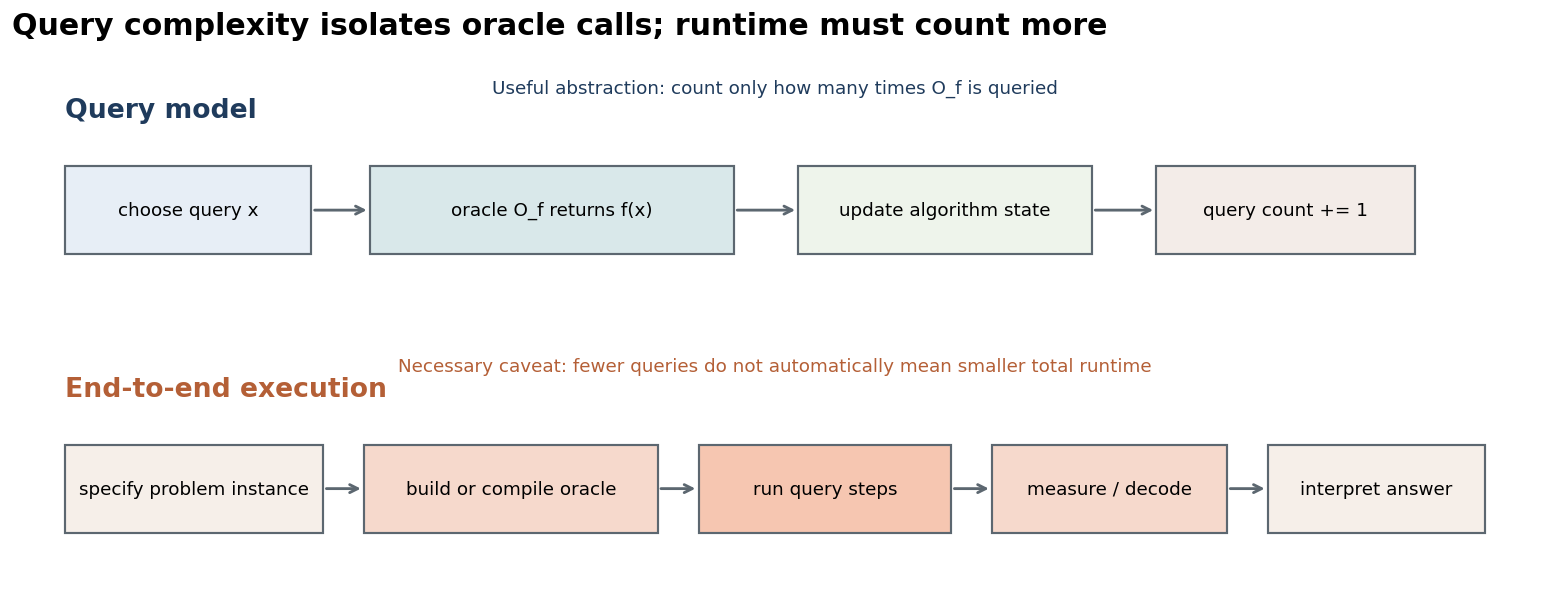

In [4]:
plot_query_model_contrast()
plt.show()


,View,Classical direct method,Oracle-based method
0,Query count only,8,1
1,End-to-end workload,9,7


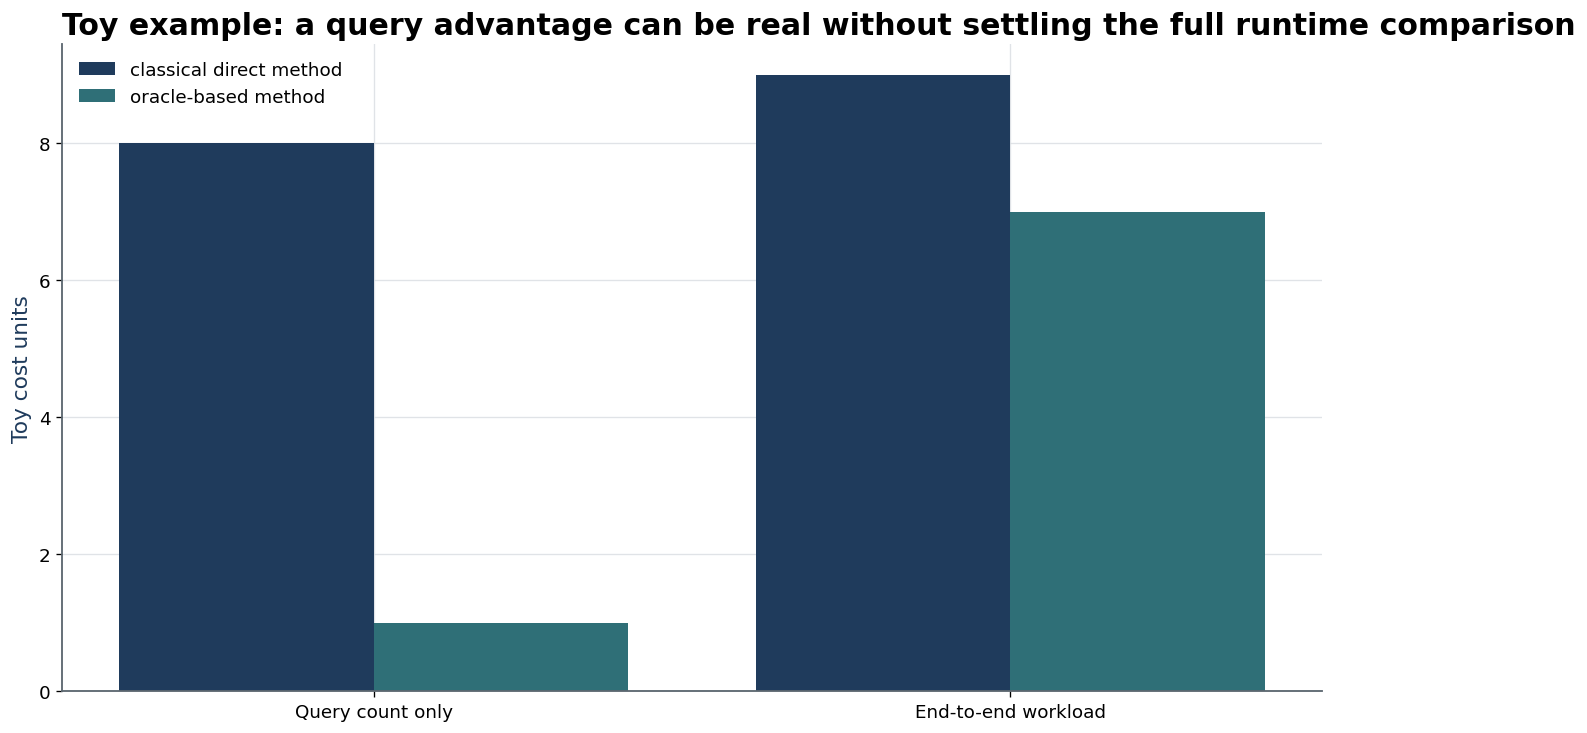

In [5]:
cost_story_df = pd.DataFrame(
    {
        'View': ['Query count only', 'End-to-end workload'],
        'Classical direct method': [8, 9],
        'Oracle-based method': [1, 7],
    }
)

display_wrapped(cost_story_df)

plot_grouped_bars(
    cost_story_df['View'],
    {
        'classical direct method': cost_story_df['Classical direct method'],
        'oracle-based method': cost_story_df['Oracle-based method'],
    },
    title='Toy example: a query advantage can be real without settling the full runtime comparison',
    ylabel='Toy cost units',
)
plt.show()


The point of the toy chart is not to claim a specific algorithmic win. It is a *discipline device*. In the query model, the oracle-based method looks much better because it asks fewer questions. In the full workflow, some of that gain can be reduced by setup and extraction costs.

This is exactly why oracle-based quantum algorithms are both exciting and easy to misread. They can show a sharp separation in **query complexity**, while still leaving open the practical cost of implementing the oracle and using the answer.

A second important bridge now appears: quantum computation is reversible. If we want an oracle to live inside a quantum circuit, it cannot simply erase information the way an arbitrary classical subroutine might. The next section makes that reversible embedding explicit.


In [6]:
display_wrapped(Markdown(markdown_box(
    'An oracle is a controlled interface to hidden information. Query complexity counts how many times we use that interface, but a complete runtime story must still count oracle construction, execution overhead, and answer extraction.',
    title='Takeaway'
)))


> **Takeaway:**
> An oracle is a controlled interface to hidden information. Query complexity counts how many times we use that interface, but a complete runtime story must still count oracle construction, execution overhead, and answer extraction.

In [7]:
display_wrapped(Markdown(markdown_box(
    'If an algorithm uses only one oracle query, that does not mean the whole computation is automatically cheap. The query model isolates one resource; it does not erase the rest of the pipeline.',
    title='Common Misconception'
)))


> **Common Misconception:**
> If an algorithm uses only one oracle query, that does not mean the whole computation is automatically cheap. The query model isolates one resource; it does not erase the rest of the pipeline.

In [8]:
display_wrapped(Markdown(instructor_prompt(
    'What kinds of hidden work would you ask about before treating an oracle query advantage as an end-to-end speedup?'
)))


> **Instructor Prompt:**
> What kinds of hidden work would you ask about before treating an oracle query advantage as an end-to-end speedup?

## 2. Visual Oracle Intuition

**Concept question:** How do we turn a classical Boolean function into a reversible quantum operation without losing the information we need later in the circuit?


A classical Boolean function may look as simple as a truth table, but quantum circuits require more structure than a table of input-output pairs. In a quantum algorithm we need a unitary transformation, so the oracle must act as a reversible permutation on basis states.

For a Boolean function `f : {0,1}^n -> {0,1}`, the standard reversible embedding is

$$
U_f |x, y\rangle = |x, y \oplus f(x)\rangle.
$$

This construction does two important things at once:
- it keeps the original input register `x` intact,
- it stores the answer into an auxiliary target bit `y` by XOR.

The result is reversible because different basis states do not collapse onto the same output. That reversibility is not a technical nuisance; it is the reason the oracle can participate coherently in interference-based algorithms.


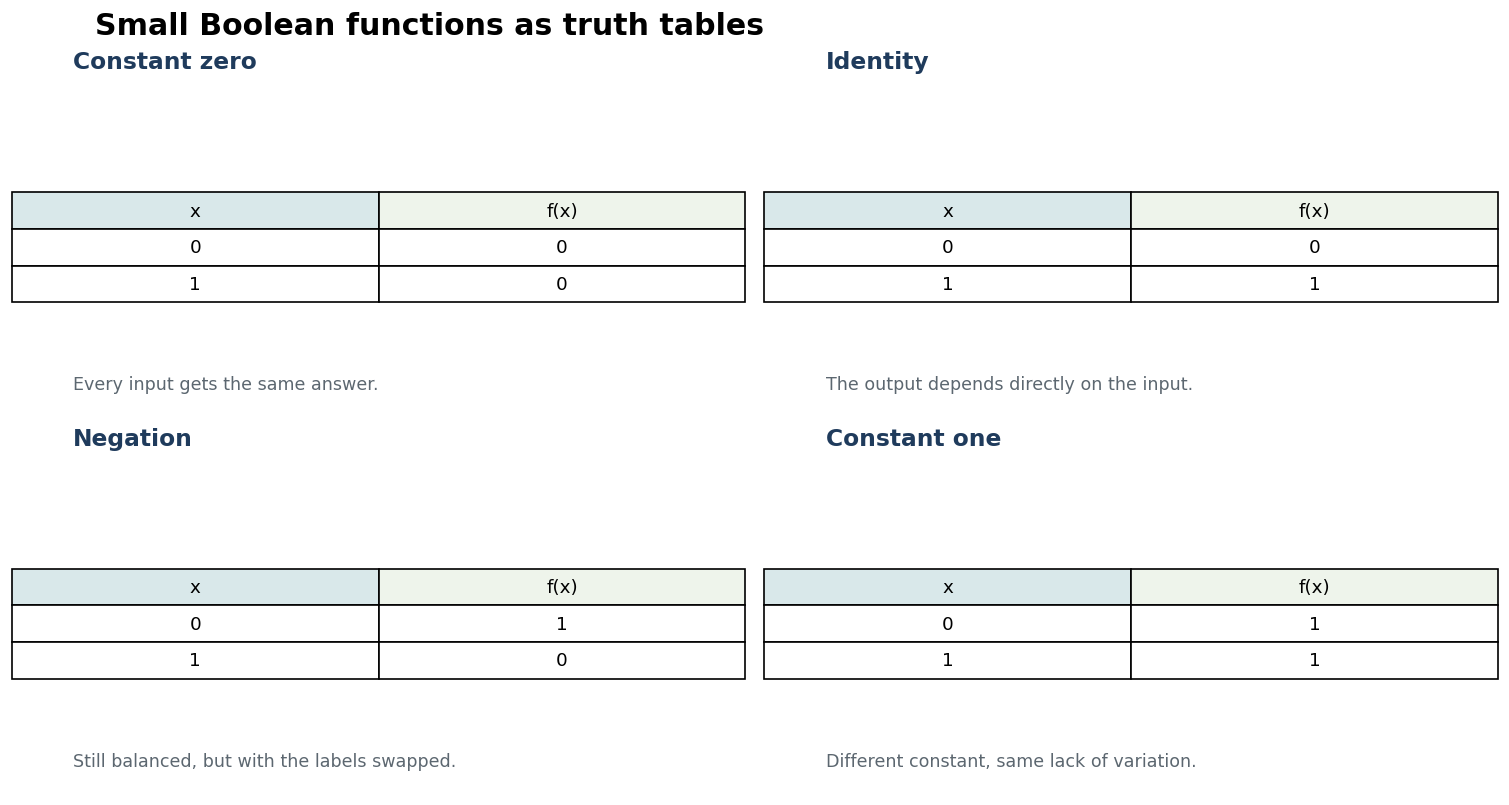

In [9]:
function_specs = [
    ('Constant zero', {'0': 0, '1': 0}, 'Every input gets the same answer.'),
    ('Identity', {'0': 0, '1': 1}, 'The output depends directly on the input.'),
    ('Negation', {'0': 1, '1': 0}, 'Still balanced, but with the labels swapped.'),
    ('Constant one', {'0': 1, '1': 1}, 'Different constant, same lack of variation.'),
]

plot_truth_table_gallery(function_specs)
plt.show()


Truth tables are the cleanest starting point because they tell us *what information the oracle encodes*. But a truth table alone does not yet tell us how to build a quantum operation. The next visual shows the key upgrade: the function is embedded into a reversible map on a larger state space.


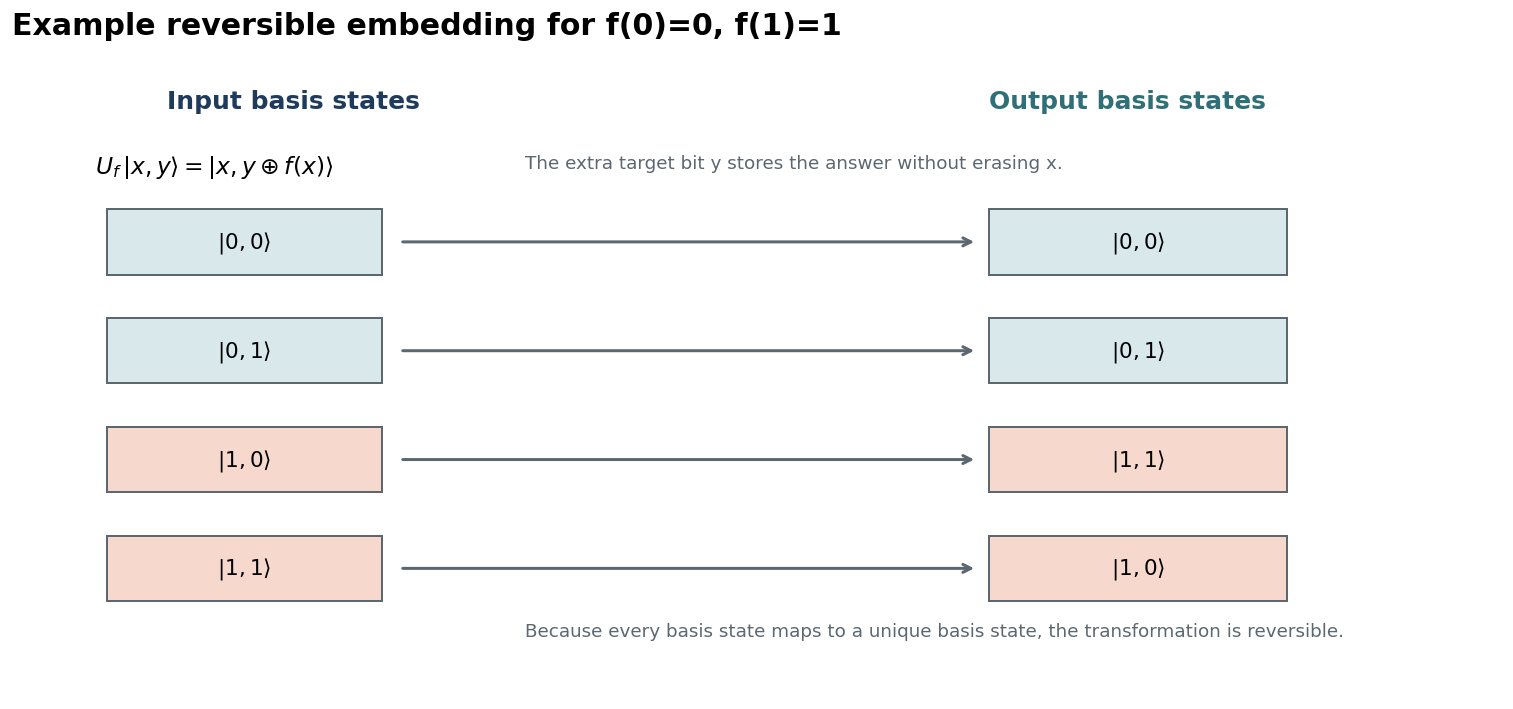

In [10]:
plot_reversible_embedding({'0': 0, '1': 1}, title='Example reversible embedding for f(0)=0, f(1)=1')
plt.show()


In many quantum algorithms, the target bit is only a temporary carrier. After a suitable preparation of that auxiliary qubit, the same Boolean information can be repackaged as a **phase mark** instead of an explicit bit value. That leads to the phase-oracle form

$$
S_f |x\rangle = (-1)^{f(x)} |x\rangle,
$$

which does not change the basis label `x` at all. Instead, it changes the *relative sign* of amplitudes. This is exactly the form that becomes useful in Deutsch-Jozsa and Grover, because interference responds to relative phase.

So the same hidden rule can be packaged in two complementary ways:
- a **bit-flip oracle** stores `f(x)` in a target register,
- a **phase oracle** marks selected basis states by a sign change.


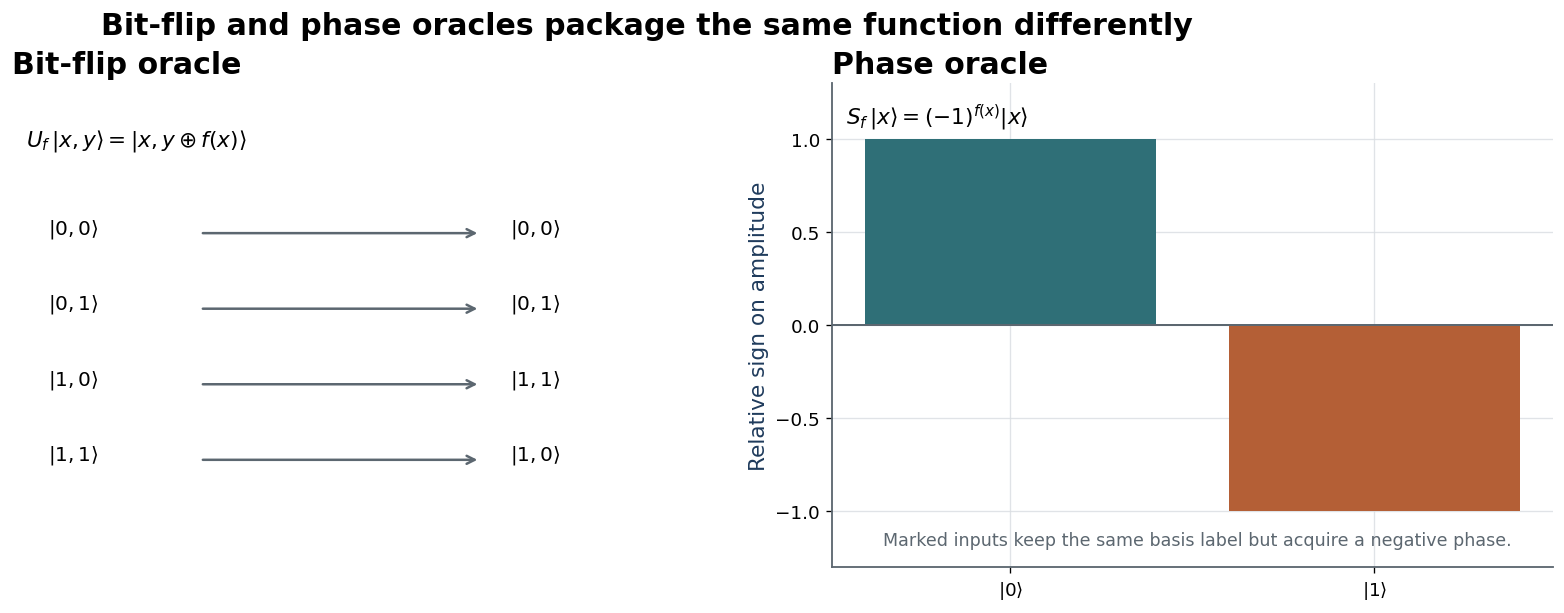

In [11]:
plot_bitflip_and_phase_oracles({'0': 0, '1': 1})
plt.show()


In [12]:
oracle_representation_df = pd.DataFrame(
    {
        'Oracle form': ['Bit-flip oracle', 'Phase oracle'],
        'Action on basis states': [
            r'$|x, y\rangle \mapsto |x, y \oplus f(x)\rangle$',
            r'$|x\rangle \mapsto (-1)^{f(x)} |x\rangle$',
        ],
        'What it makes visually obvious': [
            'Where the answer bit is stored',
            'Which states are phase-marked for interference',
        ],
        'Typical pedagogical role': [
            'Introduce reversible embedding and phase kickback',
            'Analyze algorithms built from sign marking and diffusion/interference',
        ],
    }
)

display_wrapped(oracle_representation_df)


,Oracle form,Action on basis states,What it makes visually obvious,Typical pedagogical role
0,Bit-flip oracle,"$|x, y\rangle \mapsto |x, y \oplus f(x)\rangle$",Where the answer bit is stored,Introduce reversible embedding and phase kickback
1,Phase oracle,$|x\rangle \mapsto (-1)^{f(x)} |x\rangle$,Which states are phase-marked for interference,Analyze algorithms built from sign marking and diffusion/interference


In [13]:
display_wrapped(Markdown(markdown_box(
    'A truth table tells us what function is hidden. A reversible oracle tells us how to embed that function into a unitary action. A phase oracle then repackages the same information in the form most useful for interference-based quantum algorithms.',
    title='Takeaway'
)))


> **Takeaway:**
> A truth table tells us what function is hidden. A reversible oracle tells us how to embed that function into a unitary action. A phase oracle then repackages the same information in the form most useful for interference-based quantum algorithms.

In [14]:
display_wrapped(Markdown(markdown_box(
    'A phase oracle does not hand you f(x) as a classical bit string. It changes relative phase, which only becomes observable after later interference and measurement steps.',
    title='Common Misconception'
)))


> **Common Misconception:**
> A phase oracle does not hand you f(x) as a classical bit string. It changes relative phase, which only becomes observable after later interference and measurement steps.

In [15]:
display_wrapped(Markdown(instructor_prompt(
    'Why is it useful to keep both oracle pictures in mind: one that stores the answer in a target bit and one that marks the answer as a phase?'
)))


> **Instructor Prompt:**
> Why is it useful to keep both oracle pictures in mind: one that stores the answer in a target bit and one that marks the answer as a phase?

## 3. Deutsch's Problem as the Smallest Motivating Example

**Concept question:** What is the smallest possible oracle problem where one quantum query can already reveal a global property of a hidden Boolean function?


Deutsch's problem is deliberately tiny: the hidden function has only one input bit,

$$
f : \{0,1\} 	o \{0,1\}.
$$

There are only four such functions, but they fall into two classes that matter algorithmically:
- **constant**: both inputs give the same output,
- **balanced**: one input gives `0` and the other gives `1`.

This is a useful warm-up because the problem is small enough that we can see every basis state and every phase sign explicitly. Nothing is hidden behind notation. If students understand what the oracle does here, the move to Deutsch-Jozsa is a scaling step, not a conceptual jump.


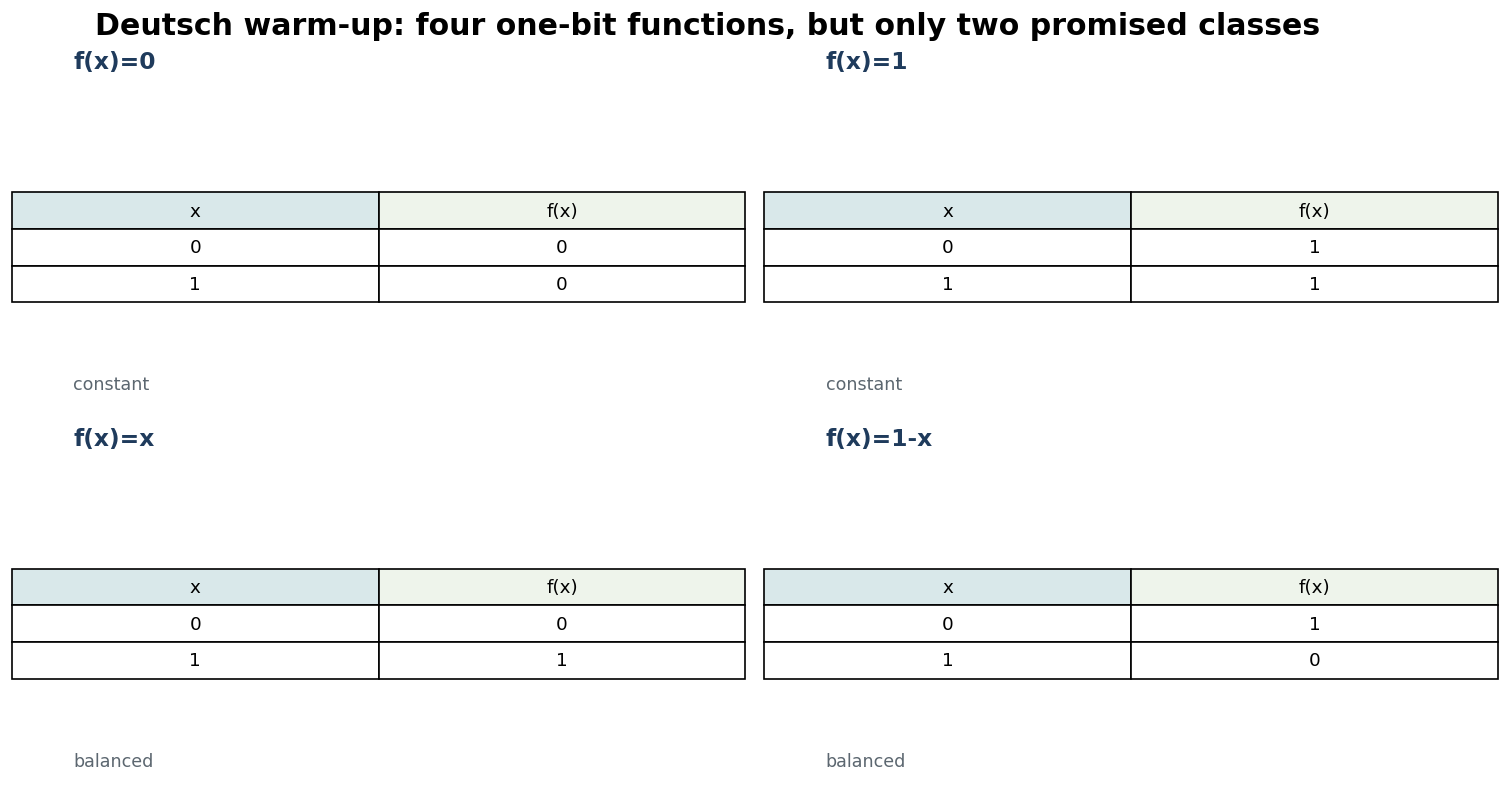

In [16]:
deutsch_function_specs = [
    ('f(x)=0', {'0': 0, '1': 0}, 'constant'),
    ('f(x)=1', {'0': 1, '1': 1}, 'constant'),
    ('f(x)=x', {'0': 0, '1': 1}, 'balanced'),
    ('f(x)=1-x', {'0': 1, '1': 0}, 'balanced'),
]

plot_truth_table_gallery(
    deutsch_function_specs,
    title='Deutsch warm-up: four one-bit functions, but only two promised classes',
)
plt.show()


Classically, one query is not enough in the worst case. After seeing only `f(0)`, we still do not know whether `f(1)` matches it or differs from it. A second query may be needed.

Quantumly, the oracle can be used in a different way. Instead of asking for one classical value, we prepare a superposition of both inputs and let the oracle write a **relative phase pattern** across them. The final Hadamard then converts that phase pattern into a measurable bit.


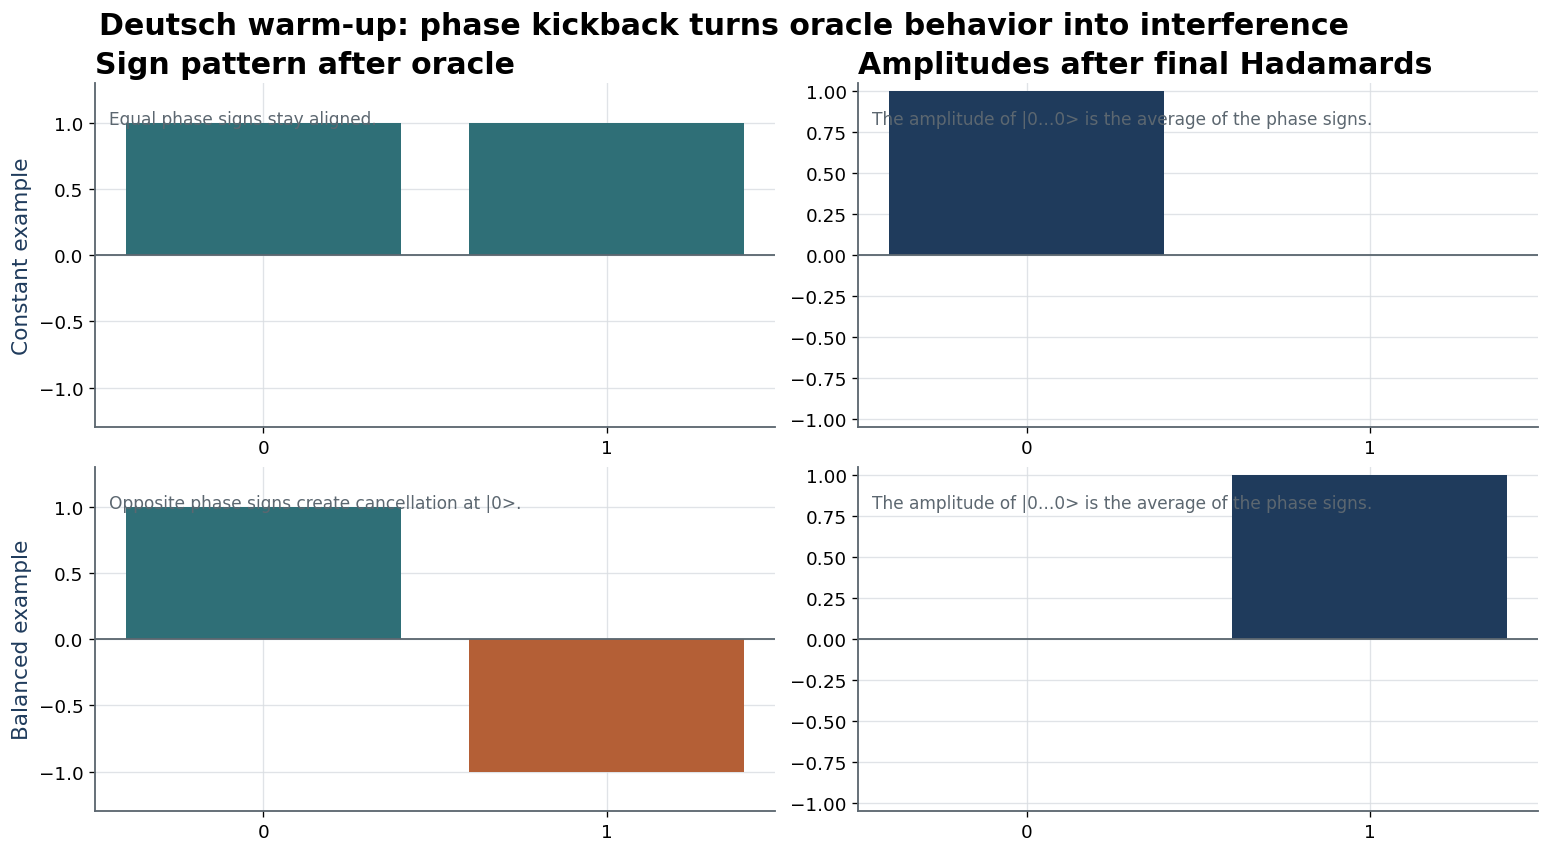

In [17]:
deutsch_phase_specs = [
    ('Constant example', {'0': 0, '1': 0}, 'Equal phase signs stay aligned.'),
    ('Balanced example', {'0': 0, '1': 1}, 'Opposite phase signs create cancellation at |0>.')
]

plot_phase_pattern_comparison(
    deutsch_phase_specs,
    title='Deutsch warm-up: phase kickback turns oracle behavior into interference',
)
plt.show()


Read the visual from left to right:
- after the oracle, the function has become a sign pattern `(+,+)` or `(+,-)`,
- after the last Hadamard, that sign pattern is turned into a basis-state preference.

For the constant example, the `|0\rangle` amplitude survives. For the balanced example, the `|0\rangle` amplitude cancels and the weight moves to `|1\rangle`. That is the whole conceptual core of Deutsch's problem.

This section is only a warm-up. Deutsch-Jozsa keeps the same logic, but now the input register has `n` qubits and the promise is "constant versus balanced" over all `2^n` inputs.


In [18]:
display_wrapped(Markdown(markdown_box(
    "Deutsch's problem is the smallest setting where oracle phase kickback is already useful. One quantum query does not reveal the full truth table; it reveals just enough global structure to distinguish the promised cases.",
    title='Takeaway'
)))


> **Takeaway:**
> Deutsch's problem is the smallest setting where oracle phase kickback is already useful. One quantum query does not reveal the full truth table; it reveals just enough global structure to distinguish the promised cases.

In [19]:
display_wrapped(Markdown(instructor_prompt(
    'In the one-bit warm-up, what new resource does the quantum circuit use that the classical one-query strategy does not: more outputs, or interference between phase-marked alternatives?'
)))


> **Instructor Prompt:**
> In the one-bit warm-up, what new resource does the quantum circuit use that the classical one-query strategy does not: more outputs, or interference between phase-marked alternatives?

## 4. Deutsch-Jozsa Theory

**Concept question:** If the hidden function has many input bits, what exactly lets one quantum query distinguish a constant oracle from a balanced one?


The **Deutsch-Jozsa promise problem** asks us to decide whether a Boolean function

$$
f : \{0,1\}^n 	o \{0,1\}
$$

is one of two special types:
- **constant**: all `2^n` inputs give the same output,
- **balanced**: exactly half of the inputs give `0` and half give `1`.

The promise matters. Without it, the question "what kind of function is this?" is too broad. A generic Boolean function could be almost anything, and one query cannot classify all possibilities. Deutsch-Jozsa is sharp precisely because it asks for one **global property** inside a restricted problem family.


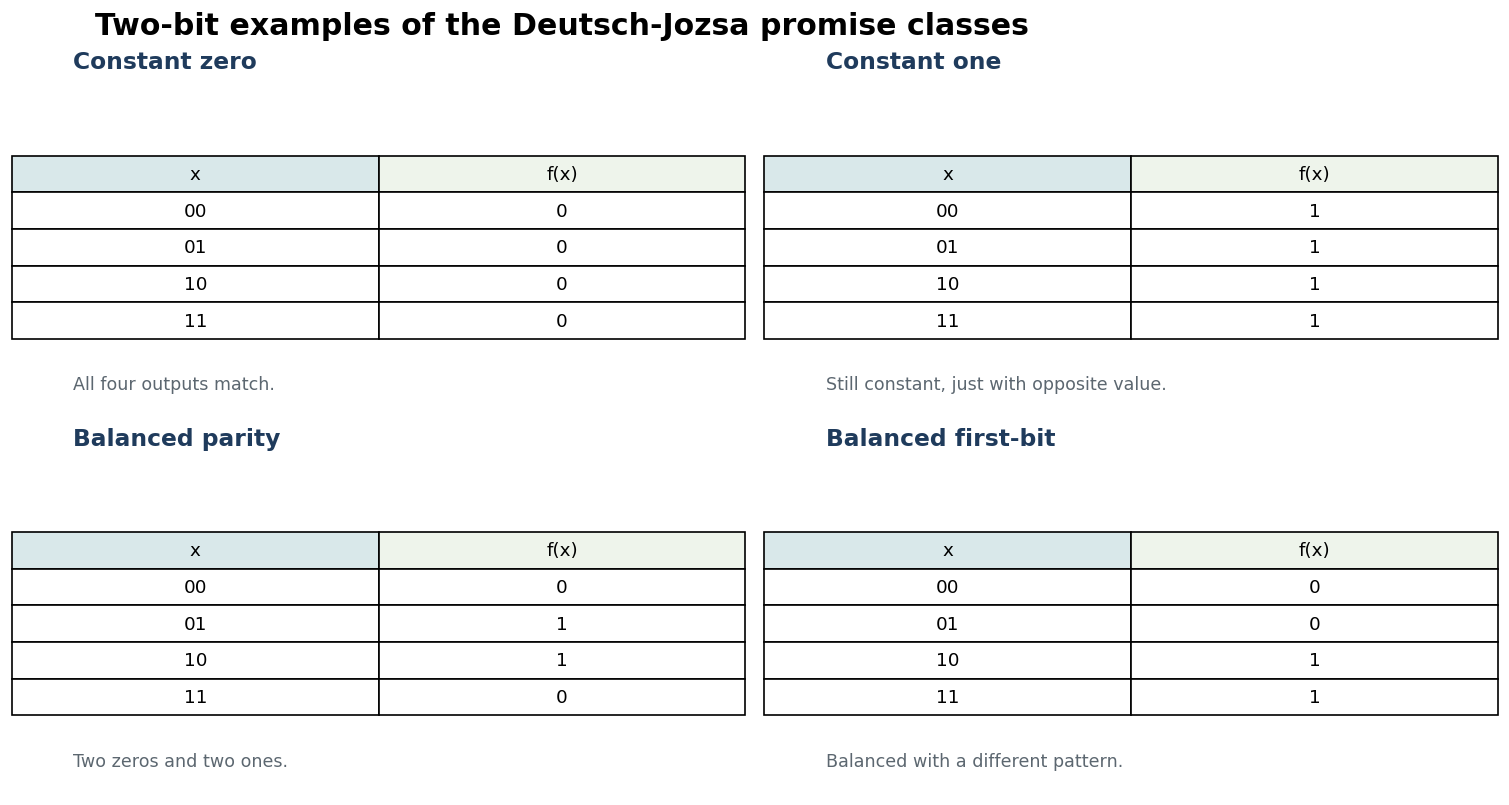

In [20]:
dj_function_specs = [
    ('Constant zero', {'00': 0, '01': 0, '10': 0, '11': 0}, 'All four outputs match.'),
    ('Constant one', {'00': 1, '01': 1, '10': 1, '11': 1}, 'Still constant, just with opposite value.'),
    ('Balanced parity', {'00': 0, '01': 1, '10': 1, '11': 0}, 'Two zeros and two ones.'),
    ('Balanced first-bit', {'00': 0, '01': 0, '10': 1, '11': 1}, 'Balanced with a different pattern.'),
]

plot_truth_table_gallery(
    dj_function_specs,
    title='Two-bit examples of the Deutsch-Jozsa promise classes',
)
plt.show()


In the classical query model, a deterministic algorithm may need to keep asking until the promise is forced. In the worst case that takes

$$
2^{n-1} + 1
$$

queries: if the first `2^{n-1}` answers all match, the function could still be constant or balanced. One more query is needed to rule one option out.

The quantum query story is different. Prepare a uniform superposition of all `x`, use the oracle once, and let phase kickback write the pattern `(-1)^{f(x)}` across the computational basis. The final Hadamards then test whether those signs add coherently at `|0^n\rangle`.


,n,Classical deterministic worst case,Quantum queries in DJ
0,n=1,2,1
1,n=2,3,1
2,n=3,5,1
3,n=4,9,1
4,n=5,17,1
5,n=6,33,1


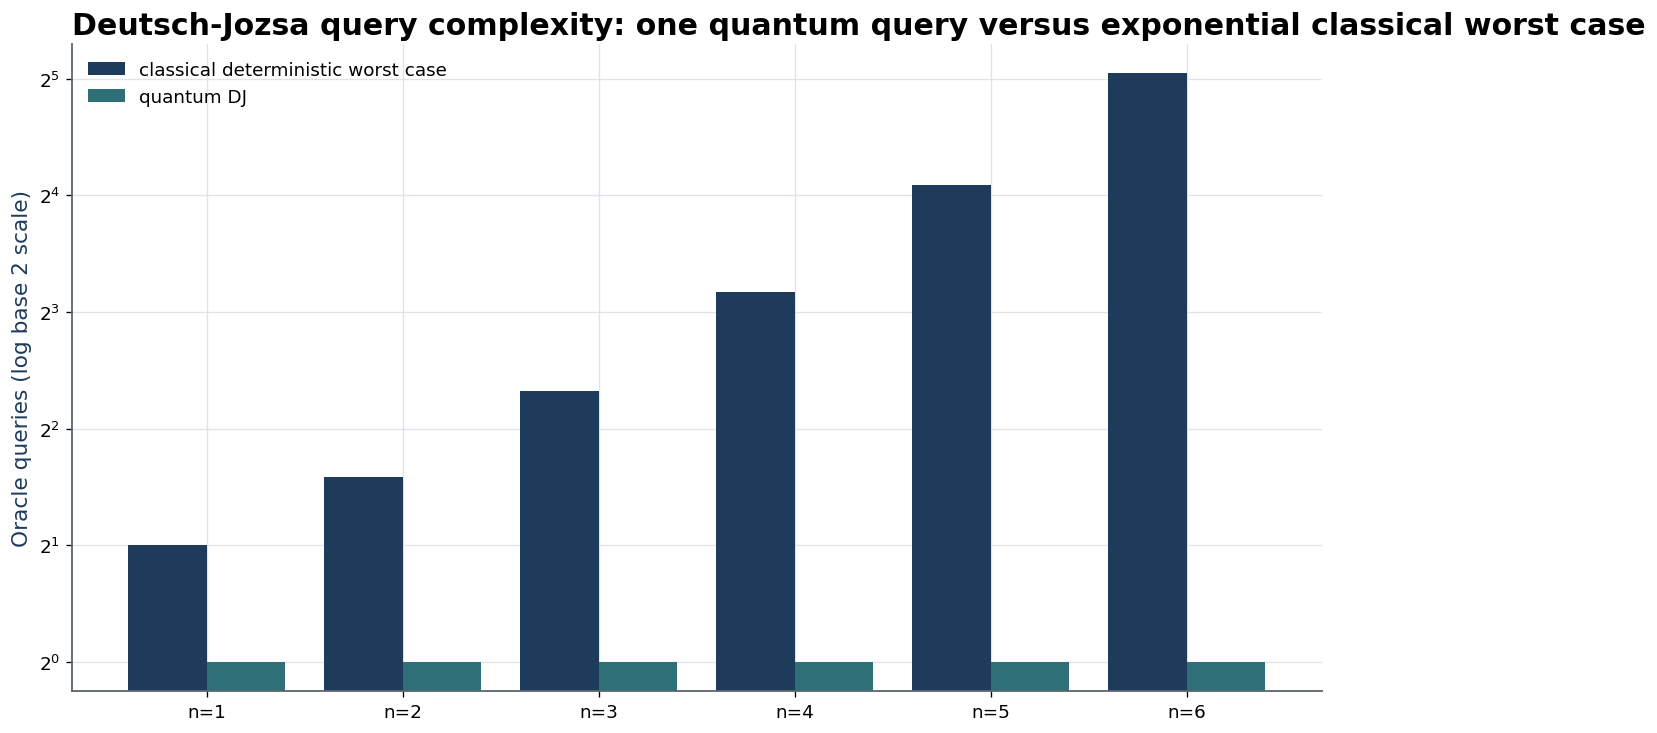

In [21]:
dj_query_sizes = np.arange(1, 7)
dj_query_df = pd.DataFrame(
    {
        'n': [f'n={n}' for n in dj_query_sizes],
        'Classical deterministic worst case': 2 ** (dj_query_sizes - 1) + 1,
        'Quantum queries in DJ': np.ones_like(dj_query_sizes),
    }
)

display_wrapped(dj_query_df)
fig, ax = plot_grouped_bars(
    dj_query_df['n'],
    {
        'classical deterministic worst case': dj_query_df['Classical deterministic worst case'],
        'quantum DJ': dj_query_df['Quantum queries in DJ'],
    },
    title='Deutsch-Jozsa query complexity: one quantum query versus exponential classical worst case',
    ylabel='Oracle queries',
)
ax.set_yscale('log', base=2)
ax.set_ylabel('Oracle queries (log base 2 scale)')
plt.show()


The key amplitude is the one on `|0^n\rangle` after the final Hadamards. Its value is

$$
\frac{1}{2^n} \sum_x (-1)^{f(x)}.
$$

Now the promise does all the work:
- if `f` is constant, every sign is the same, so the sum has magnitude `1`,
- if `f` is balanced, half the signs are `+1` and half are `-1`, so the sum is `0`.

So the circuit is not learning the full function table. It is learning whether the oracle's phase pattern has a nonzero average or cancels exactly.


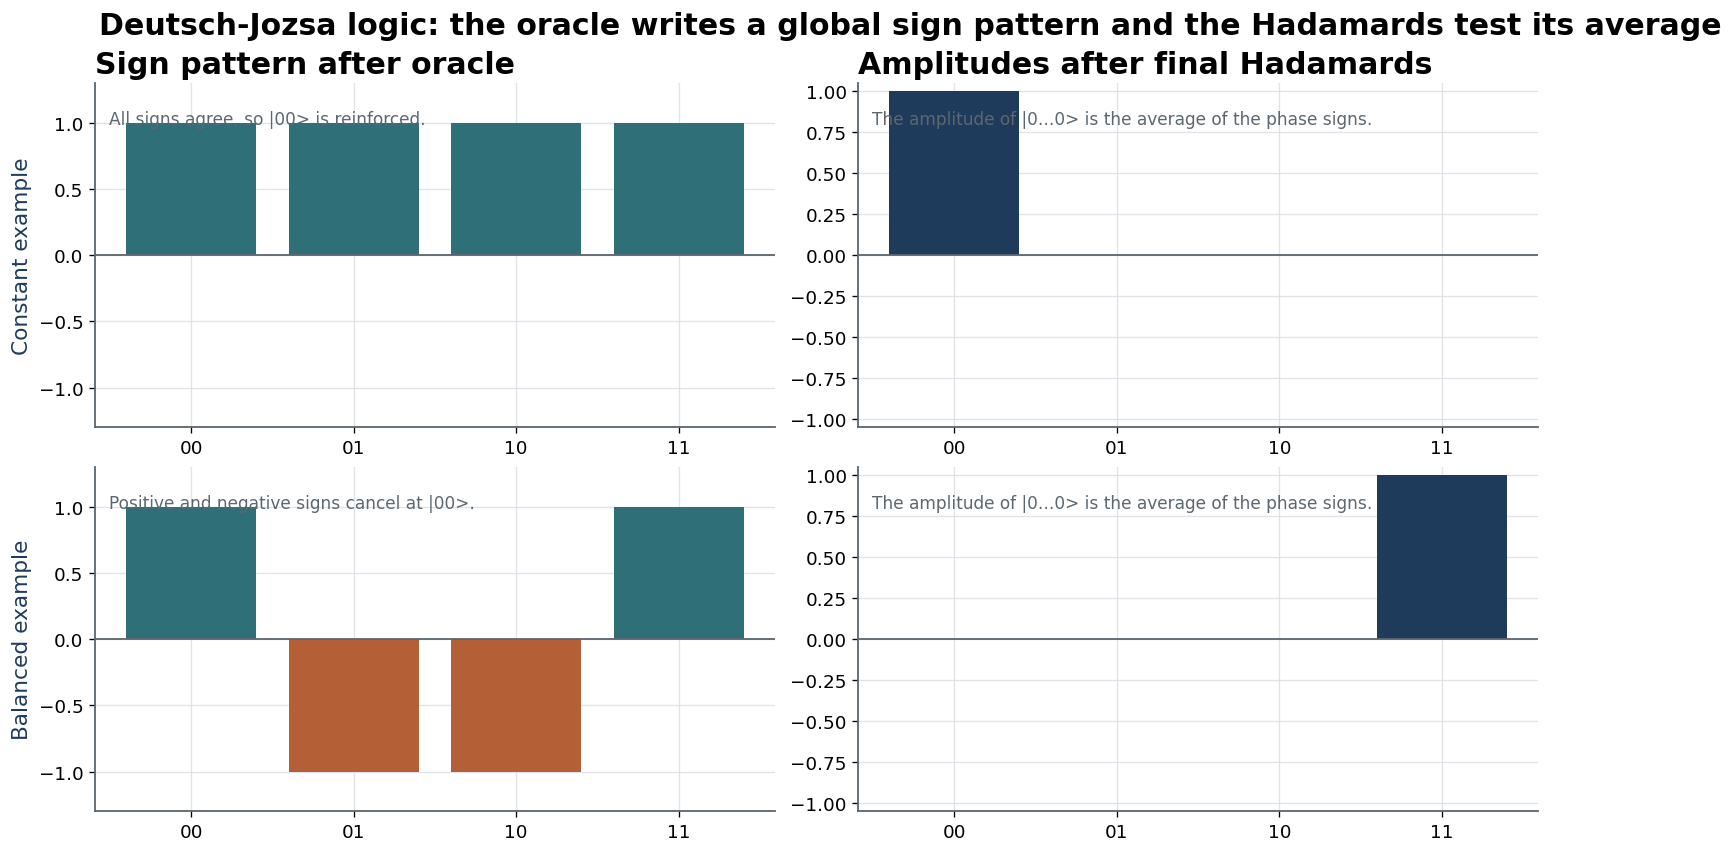

In [22]:
dj_phase_specs = [
    ('Constant example', {'00': 0, '01': 0, '10': 0, '11': 0}, 'All signs agree, so |00> is reinforced.'),
    ('Balanced example', {'00': 0, '01': 1, '10': 1, '11': 0}, 'Positive and negative signs cancel at |00>.')
]

plot_phase_pattern_comparison(
    dj_phase_specs,
    title='Deutsch-Jozsa logic: the oracle writes a global sign pattern and the Hadamards test its average',
)
plt.show()


This visual is a teaching aid, but it captures the exact logic of the algorithm. The left column shows what the oracle contributes: a structured pattern of plus and minus signs. The right column shows what the final Hadamards reveal: whether those signs add coherently at the all-zero string.


In [23]:
display_wrapped(Markdown(markdown_box(
    'Deutsch-Jozsa does not give a generic speedup for arbitrary function analysis. The separation is a one-query versus many-query result inside a promise problem where the oracle is assumed to be available.',
    title='Common Misconception'
)))


> **Common Misconception:**
> Deutsch-Jozsa does not give a generic speedup for arbitrary function analysis. The separation is a one-query versus many-query result inside a promise problem where the oracle is assumed to be available.

In [24]:
display_wrapped(Markdown(markdown_box(
    'The promise is essential. Constant functions have a nonzero average sign, balanced functions have zero average sign, and the final Hadamards convert that difference into an all-zero versus nonzero measurement pattern.',
    title='Takeaway'
)))


> **Takeaway:**
> The promise is essential. Constant functions have a nonzero average sign, balanced functions have zero average sign, and the final Hadamards convert that difference into an all-zero versus nonzero measurement pattern.

In [25]:
display_wrapped(Markdown(instructor_prompt(
    'Why is the promise doing real algorithmic work here? What would become ambiguous if the oracle were allowed to be an arbitrary Boolean function instead of only constant or balanced?'
)))


> **Instructor Prompt:**
> Why is the promise doing real algorithmic work here? What would become ambiguous if the oracle were allowed to be an arbitrary Boolean function instead of only constant or balanced?

## 5. Deutsch-Jozsa in Qiskit

**Concept question:** What does a small Deutsch-Jozsa oracle look like as an actual circuit, and how does the predicted all-zero versus nonzero pattern appear in simulation?


For the executable examples below, we keep the construction intentionally transparent. The oracle is built directly from the function table: for each input `x` with `f(x)=1`, we flip the target ancilla on that basis state. When the ancilla is prepared in `| - \rangle`, that bit-flip action becomes phase kickback.

These are still toy teaching examples. The point is to let students inspect the oracle rather than hide it inside a library object.


In [26]:
def outputs_to_mapping(outputs):
    outputs = ''.join(str(bit) for bit in outputs)
    n = int(np.log2(len(outputs)))
    return {format(index, f'0{n}b'): int(bit) for index, bit in enumerate(outputs)}


def deutsch_jozsa_oracle(outputs, *, name='U_f'):
    outputs = ''.join(str(bit) for bit in outputs)
    n = int(np.log2(len(outputs)))
    oracle = QuantumCircuit(n + 1, name=name)
    target = n

    # For every input x with f(x)=1, flip the ancilla only on that basis state.
    for index, bit in enumerate(outputs):
        if bit != '1':
            continue
        bitstring = format(index, f'0{n}b')
        zero_qubits = [qubit for qubit, char in enumerate(reversed(bitstring)) if char == '0']
        for qubit in zero_qubits:
            oracle.x(qubit)
        if n == 1:
            oracle.cx(0, target)
        else:
            oracle.mcx(list(range(n)), target)
        for qubit in zero_qubits:
            oracle.x(qubit)

    return oracle


def build_dj_circuit(outputs, *, name='DJ circuit'):
    outputs = ''.join(str(bit) for bit in outputs)
    n = int(np.log2(len(outputs)))
    oracle = deutsch_jozsa_oracle(outputs, name='U_f')
    circuit = QuantumCircuit(n + 1, n, name=name)

    circuit.x(n)
    circuit.h(n)
    circuit.h(range(n))
    circuit.barrier()
    circuit.append(oracle.to_gate(), range(n + 1))
    circuit.barrier()
    circuit.h(range(n))
    circuit.measure(range(n), range(n))
    return circuit, oracle


def build_dj_state_circuit(outputs):
    outputs = ''.join(str(bit) for bit in outputs)
    n = int(np.log2(len(outputs)))
    oracle = deutsch_jozsa_oracle(outputs, name='U_f')
    circuit = QuantumCircuit(n + 1)
    circuit.x(n)
    circuit.h(n)
    circuit.h(range(n))
    circuit.append(oracle.to_gate(), range(n + 1))
    circuit.h(range(n))
    return circuit


def dj_input_probabilities(outputs):
    outputs = ''.join(str(bit) for bit in outputs)
    mapping = outputs_to_mapping(outputs)
    labels = sorted(mapping)
    n = len(labels[0])
    state = Statevector.from_instruction(build_dj_state_circuit(outputs))
    probabilities = state.probabilities_dict(qargs=list(range(n)))
    return {label: float(probabilities.get(label, 0.0)) for label in labels}


def run_dj_counts(outputs, *, shots=1024, seed=7):
    outputs = ''.join(str(bit) for bit in outputs)
    mapping = outputs_to_mapping(outputs)
    labels = sorted(mapping)
    n = len(labels[0])
    state = Statevector.from_instruction(build_dj_state_circuit(outputs))
    np.random.seed(seed)
    sampled = state.sample_counts(shots=shots, qargs=list(range(n)))
    counts = {label: int(sampled.get(label, 0)) for label in labels}
    circuit, oracle = build_dj_circuit(outputs)
    return circuit, oracle, counts


,Example,Output string f(00)f(01)f(10)f(11),Promise class
0,Constant 0 (n=2),0000,constant
1,Constant 1 (n=2),1111,constant
2,Balanced parity (n=2),0110,balanced
3,Balanced first-bit (n=2),0011,balanced


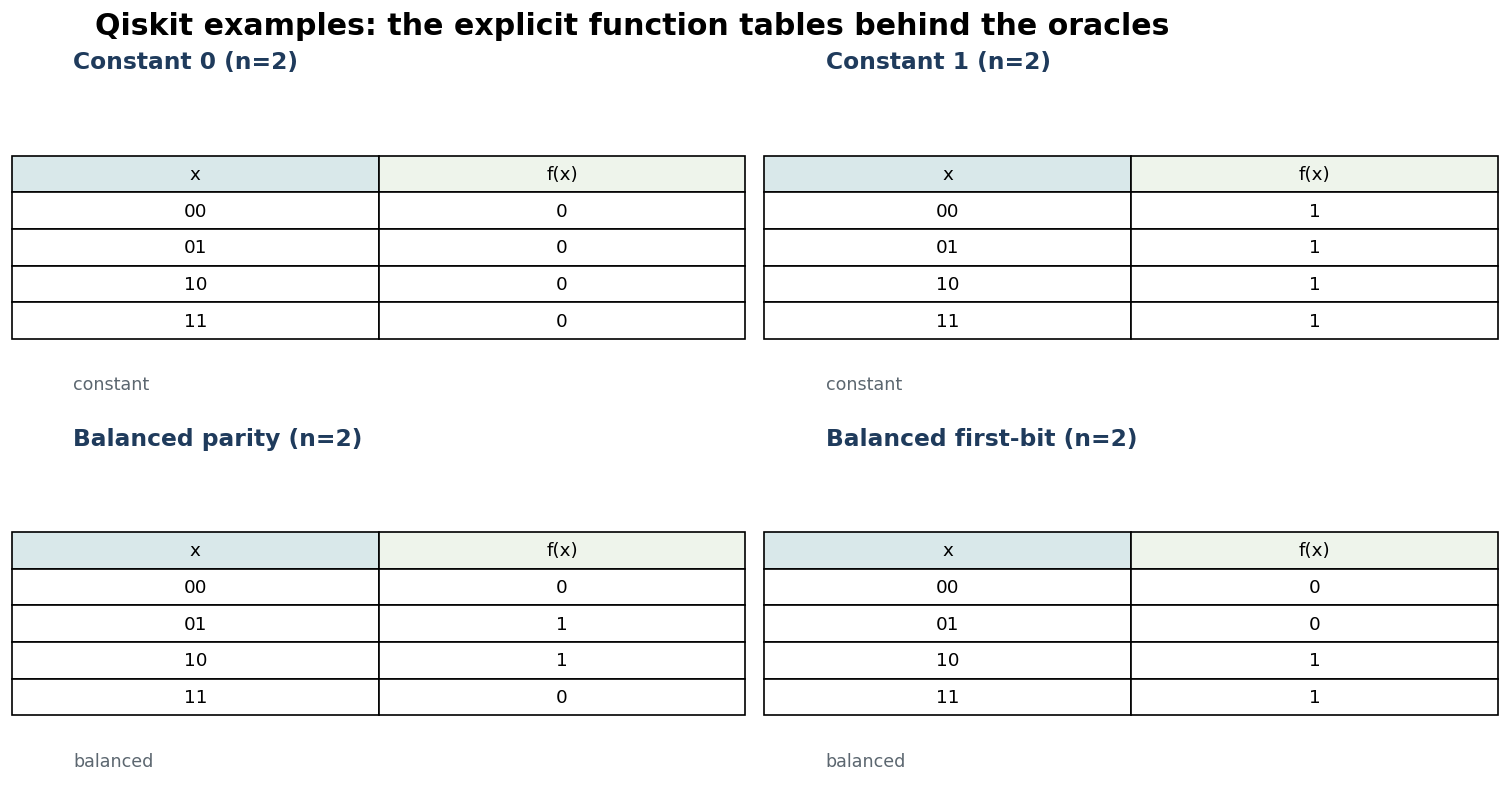

In [27]:
dj_examples = {
    'Constant 0 (n=2)': '0000',
    'Constant 1 (n=2)': '1111',
    'Balanced parity (n=2)': '0110',
    'Balanced first-bit (n=2)': '0011',
}

dj_examples_df = pd.DataFrame(
    {
        'Example': list(dj_examples.keys()),
        'Output string f(00)f(01)f(10)f(11)': list(dj_examples.values()),
        'Promise class': ['constant', 'constant', 'balanced', 'balanced'],
    }
)

display_wrapped(dj_examples_df)

plot_truth_table_gallery(
    [(name, outputs_to_mapping(outputs), promise) for name, outputs, promise in zip(dj_examples_df['Example'], dj_examples_df['Output string f(00)f(01)f(10)f(11)'], dj_examples_df['Promise class'])],
    title='Qiskit examples: the explicit function tables behind the oracles',
)
plt.show()


**Constant 1 (n=2): oracle circuit only**

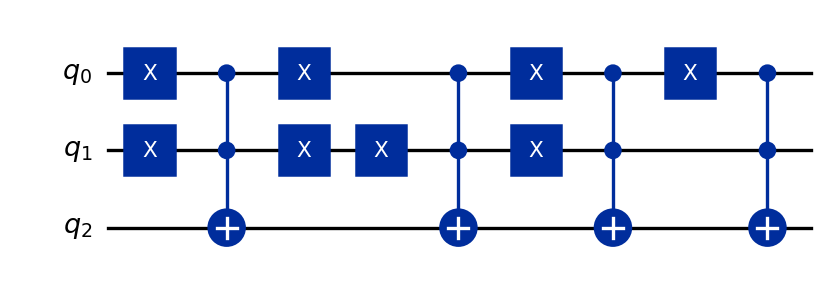

**Balanced parity (n=2): oracle circuit only**

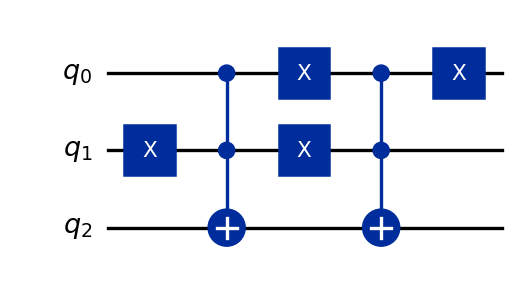

In [28]:
for name in ['Constant 1 (n=2)', 'Balanced parity (n=2)']:
    display(Markdown(f'**{name}: oracle circuit only**'))
    display(deutsch_jozsa_oracle(dj_examples[name], name='U_f').draw('mpl'))


The oracle drawings are worth reading slowly. The construction is not magic: the ancilla is flipped exactly on the basis states where the truth table says `f(x)=1`. For a constant-one oracle, every input is marked. For a balanced oracle, only half of the inputs are marked.

Once the ancilla starts in `| - \rangle`, those flips become phase signs on the input superposition, which is exactly the behavior we visualized in the theory section.


**Constant 1 (n=2): full Deutsch-Jozsa circuit**

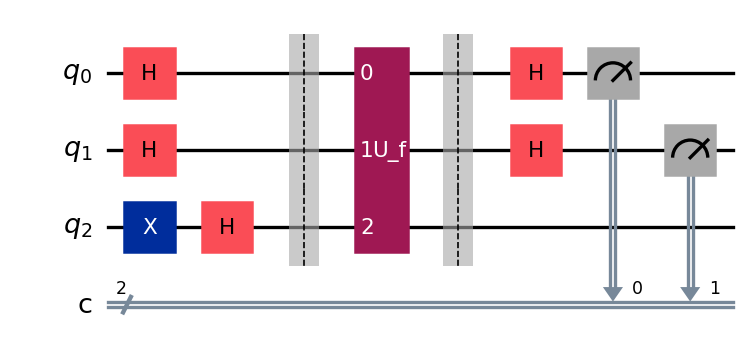

**Balanced parity (n=2): full Deutsch-Jozsa circuit**

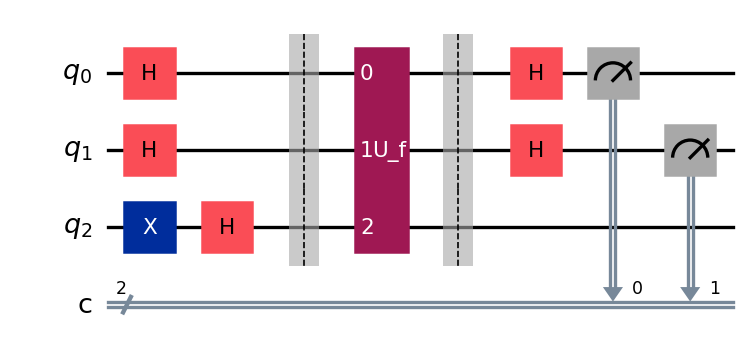

In [29]:
for name in ['Constant 1 (n=2)', 'Balanced parity (n=2)']:
    circuit, _ = build_dj_circuit(dj_examples[name], name=name)
    display(Markdown(f'**{name}: full Deutsch-Jozsa circuit**'))
    display(circuit.draw('mpl'))


,Example,Exact P(00) before measurement,Most likely sampled output
0,Constant 0 (n=2),1,00
1,Constant 1 (n=2),1,00
2,Balanced parity (n=2),3.69e-70,11
3,Balanced first-bit (n=2),9.07e-35,10


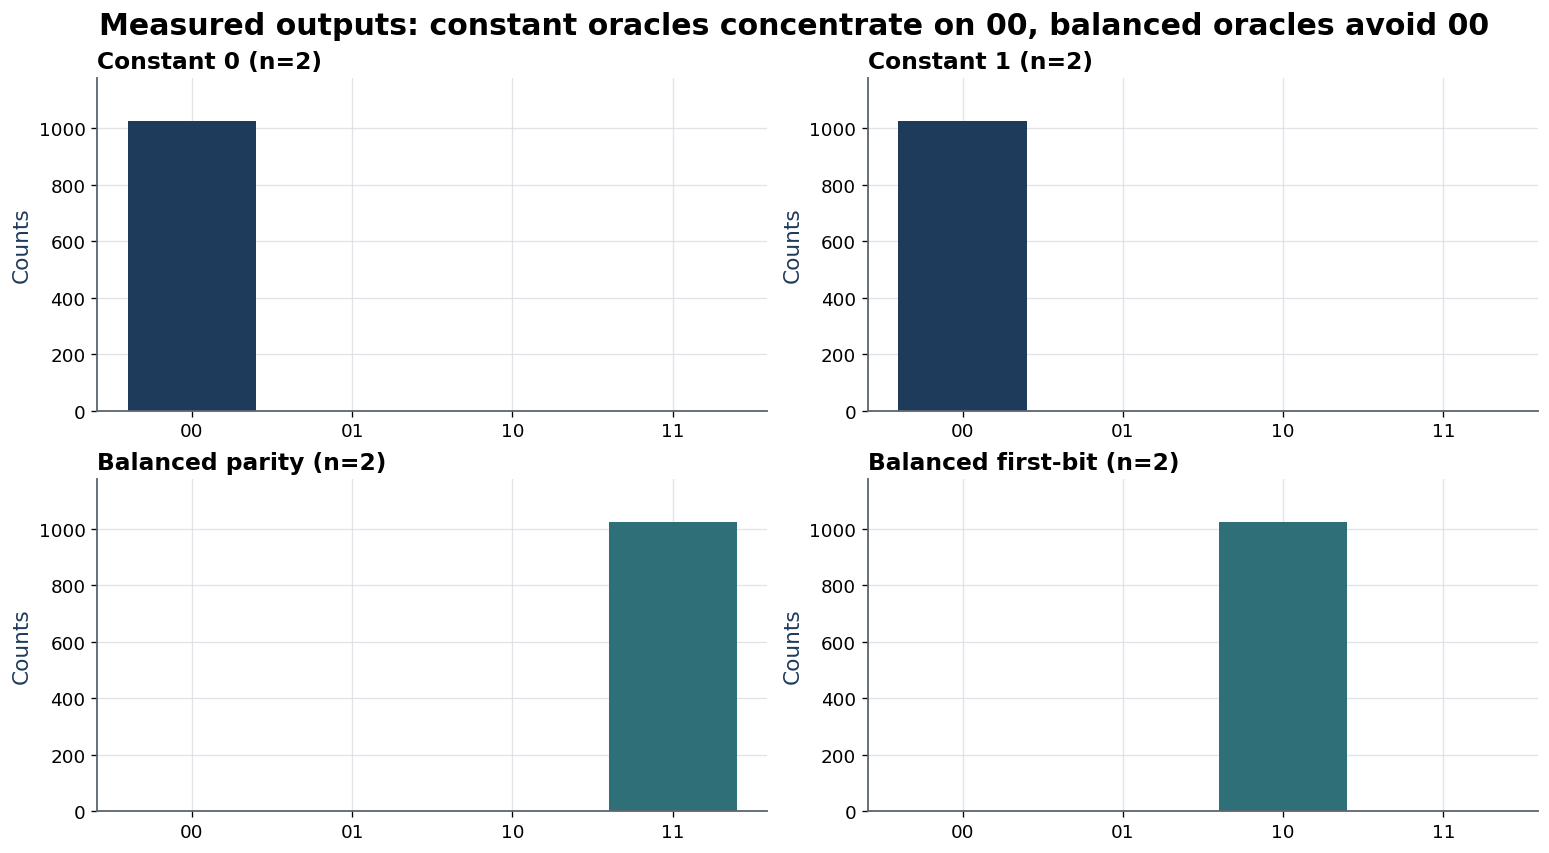

In [30]:
counts_by_example = {}
probability_rows = []
for name, outputs in dj_examples.items():
    circuit, oracle, counts = run_dj_counts(outputs, shots=1024)
    counts_by_example[name] = {label: counts.get(label, 0) for label in sorted(dj_input_probabilities(outputs))}
    exact_probs = dj_input_probabilities(outputs)
    probability_rows.append(
        {
            'Example': name,
            'Exact P(00) before measurement': exact_probs.get('00', 0.0),
            'Most likely sampled output': max(counts, key=counts.get),
        }
    )

probability_summary_df = pd.DataFrame(probability_rows)
display_wrapped(probability_summary_df)
plot_counts_grid(
    counts_by_example,
    title='Measured outputs: constant oracles concentrate on 00, balanced oracles avoid 00',
)
plt.show()


The simulation matches the theory cleanly:
- for the constant examples, the input register concentrates on `00`,
- for the balanced examples, the probability of `00` vanishes and another bit string becomes dominant.

That second point matters. The Deutsch-Jozsa circuit is not trying to identify *which* balanced function was used. It only needs enough interference structure to say "not constant." The all-zero string is therefore the decision marker: under the promise, measuring `00...0` means constant, and measuring anything else means balanced.


In [31]:
display_wrapped(Markdown(markdown_box(
    'In the Qiskit implementation, the oracle is still just a reversible circuit encoding the truth table. The Deutsch-Jozsa algorithm uses one oracle call, phase kickback, and final Hadamards to test whether the average phase is nonzero.',
    title='Takeaway'
)))


> **Takeaway:**
> In the Qiskit implementation, the oracle is still just a reversible circuit encoding the truth table. The Deutsch-Jozsa algorithm uses one oracle call, phase kickback, and final Hadamards to test whether the average phase is nonzero.

In [32]:
display_wrapped(Markdown(instructor_prompt(
    'If two different balanced functions can produce different nonzero output strings, why is the all-zero versus nonzero decision rule still enough for the Deutsch-Jozsa promise problem?'
)))


> **Instructor Prompt:**
> If two different balanced functions can produce different nonzero output strings, why is the all-zero versus nonzero decision rule still enough for the Deutsch-Jozsa promise problem?

## 6. Grover Theory

**Concept question:** If the oracle marks good candidates only by phase, how can repeated reflections turn that hidden mark into a large measurement probability?


Grover's search algorithm addresses a different oracle question from Deutsch-Jozsa. Instead of asking whether a whole function is constant or balanced, we assume a search space of `N = 2^n` indexed candidates and a Boolean oracle that answers

$$
f(x) =
\begin{cases}
1 & \text{if } x \text{ is a good candidate,} \\
0 & \text{otherwise.}
\end{cases}
$$

In the quantum version, the oracle is usually used as a **phase marker**,

$$
S_f |x\rangle = (-1)^{f(x)} |x\rangle,
$$

so the marked states do not get a bigger amplitude immediately. They only get a minus sign. Grover's algorithm then adds a second transformation, the **diffusion operator**, which reflects all amplitudes about their mean. The algorithm is therefore not "search by magic." It is **mark + reflect + amplify**.


In [33]:
def grover_oracle_on_amplitudes(labels, amplitudes, marked_labels):
    marked_labels = set(marked_labels)
    updated = amplitudes.copy()
    for index, label in enumerate(labels):
        if label in marked_labels:
            updated[index] *= -1
    return updated


def diffusion_on_amplitudes(amplitudes):
    mean_amplitude = amplitudes.mean()
    return 2 * mean_amplitude - amplitudes


def grover_iteration_stages(labels, marked_labels):
    initial = np.full(len(labels), 1 / np.sqrt(len(labels)), dtype=float)
    after_oracle = grover_oracle_on_amplitudes(labels, initial, marked_labels)
    after_diffusion = diffusion_on_amplitudes(after_oracle)
    return initial, after_oracle, after_diffusion


def plot_signed_amplitudes(labels, amplitude_sets, panel_titles, *, marked_labels=None, title='Amplitude view'):
    marked_labels = set(marked_labels or [])
    fig, axes = plt.subplots(1, len(amplitude_sets), figsize=(4.2 * len(amplitude_sets) + 0.8, 4.8), constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax, amplitudes, panel_title in zip(axes, amplitude_sets, panel_titles):
        bars = ax.bar(labels, amplitudes, color=COLORS['teal'])
        for bar, label, amplitude in zip(bars, labels, amplitudes):
            if label in marked_labels:
                bar.set_edgecolor(COLORS['navy'])
                bar.set_linewidth(1.6)
                bar.set_facecolor(COLORS['gold'] if amplitude >= 0 else COLORS['rust'])
        ax.axhline(0, color=COLORS['gray'], linewidth=1.0)
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(panel_title, loc='left')
        ax.set_ylabel('Amplitude')
        if len(labels) > 4:
            ax.tick_params(axis='x', rotation=20)

    fig.suptitle(title, x=0.06, ha='left', fontsize=18, fontweight='semibold')
    return fig, axes


def grover_success_probability(total_states, iterations, *, num_marked=1):
    theta = np.arcsin(np.sqrt(num_marked / total_states))
    return np.sin((2 * iterations + 1) * theta) ** 2


def plot_good_bad_rotation(total_states, *, num_marked=1, max_iterations=4, title='Teaching aid: Grover as rotation in the good/bad subspace'):
    theta = np.arcsin(np.sqrt(num_marked / total_states))
    optimal_iteration = int(np.round(np.pi / (4 * theta) - 0.5))

    fig, ax = plt.subplots(figsize=(6.2, 6.0), constrained_layout=True)
    ax.set_xlim(-0.1, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Bad-subspace component')
    ax.set_ylabel('Good-subspace component')
    ax.set_title(title, loc='left')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.axhline(0, color=COLORS['gray'], linewidth=1.0)
    ax.axvline(0, color=COLORS['gray'], linewidth=1.0)
    ax.plot([0, 0], [0, 1], color=COLORS['gold'], linestyle='--', linewidth=1.4)
    ax.text(0.03, 0.98, '|good>', color=COLORS['gold'], va='top')

    for iteration in range(max_iterations + 1):
        angle = (2 * iteration + 1) * theta
        x_coord = np.cos(angle)
        y_coord = np.sin(angle)
        color = COLORS['navy'] if iteration == optimal_iteration else COLORS['teal']
        ax.annotate('', xy=(x_coord, y_coord), xytext=(0, 0), arrowprops={'arrowstyle': '->', 'linewidth': 2.0, 'color': color})
        label = f'r={iteration}'
        if iteration == optimal_iteration:
            label += ' (near-optimal)'
        ax.text(x_coord + 0.02, y_coord, label, color=color, fontsize=10)

    ax.text(0.55, 0.12, 'Each Grover iteration rotates the state\nby another 2 theta toward |good>.', color=COLORS['gray'])
    return fig, ax


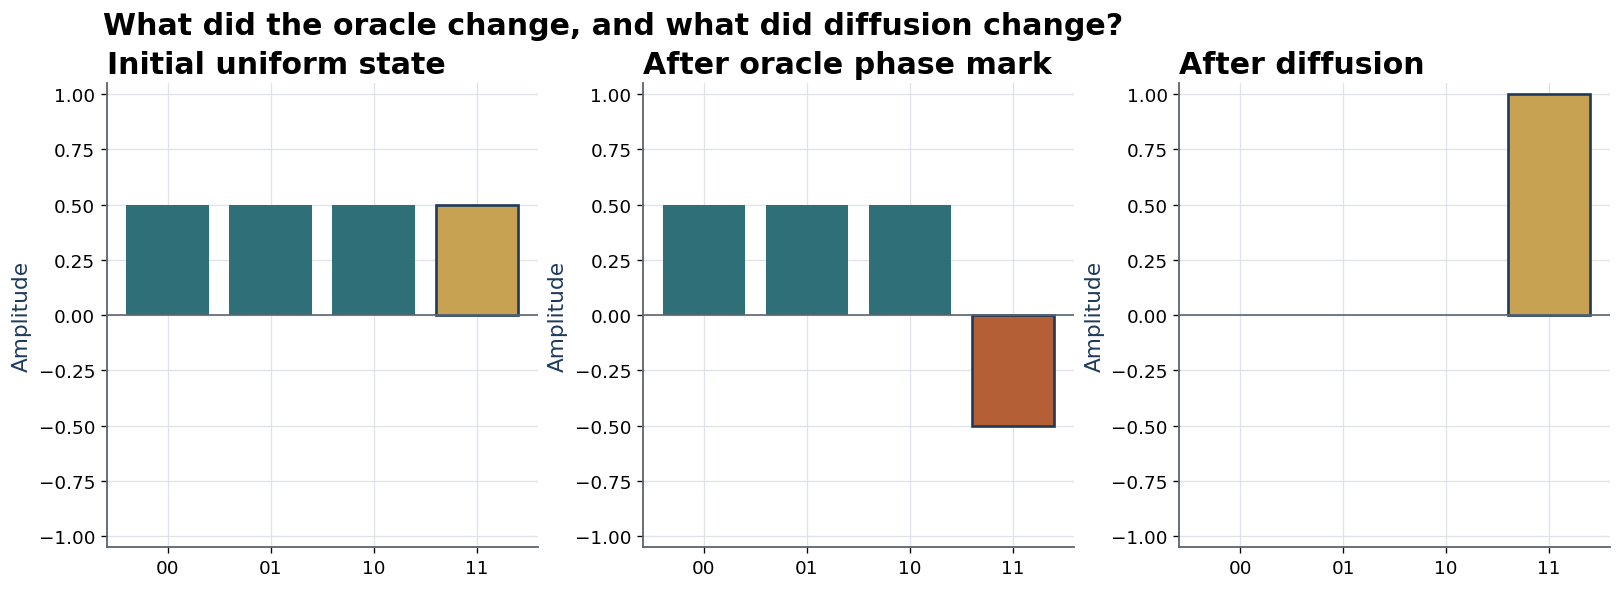

In [34]:
grover_labels = bitstrings(2)
grover_marked = {'11'}
initial_amplitudes, after_oracle_amplitudes, after_diffusion_amplitudes = grover_iteration_stages(grover_labels, grover_marked)

plot_signed_amplitudes(
    grover_labels,
    [initial_amplitudes, after_oracle_amplitudes, after_diffusion_amplitudes],
    ['Initial uniform state', 'After oracle phase mark', 'After diffusion'],
    marked_labels=grover_marked,
    title='What did the oracle change, and what did diffusion change?'
)
plt.show()


This first Grover visual answers two different questions.

The **oracle** changes only the sign of the marked state. In the example above, `|11\rangle` does not become larger immediately; it becomes negative relative to the others.

The **diffusion operator** then reflects all amplitudes about their mean. Because the marked state was below the mean after the oracle, reflection sends it above the mean. The unmarked states move down slightly. That is the amplification step.


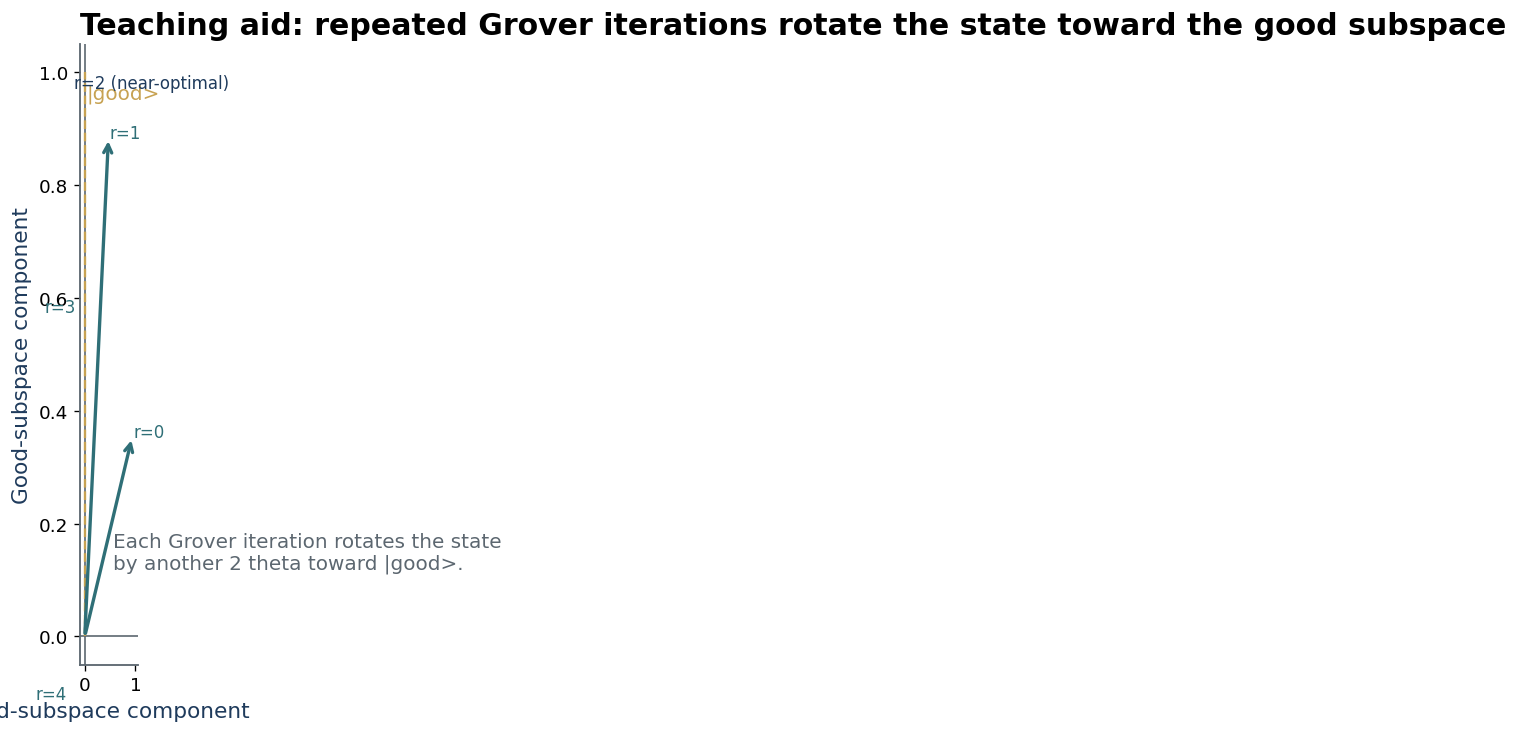

In [35]:
plot_good_bad_rotation(
    total_states=8,
    num_marked=1,
    max_iterations=4,
    title='Teaching aid: repeated Grover iterations rotate the state toward the good subspace',
)
plt.show()


The good/bad-subspace picture is a compact way to summarize many basis states at once.

If `M` out of `N` candidates are marked, define `|good\rangle` as the normalized superposition of the marked states and `|bad\rangle` as the normalized superposition of the unmarked states. The initial uniform state is already a vector in the plane spanned by those two directions. Each Grover iteration rotates that vector toward `|good\rangle` by a fixed angle.

That explains why the iteration count matters. Too few iterations leave too much weight in the bad subspace. Near the optimal count, the state is closest to `|good\rangle`. Too many iterations overshoot and rotate away again.


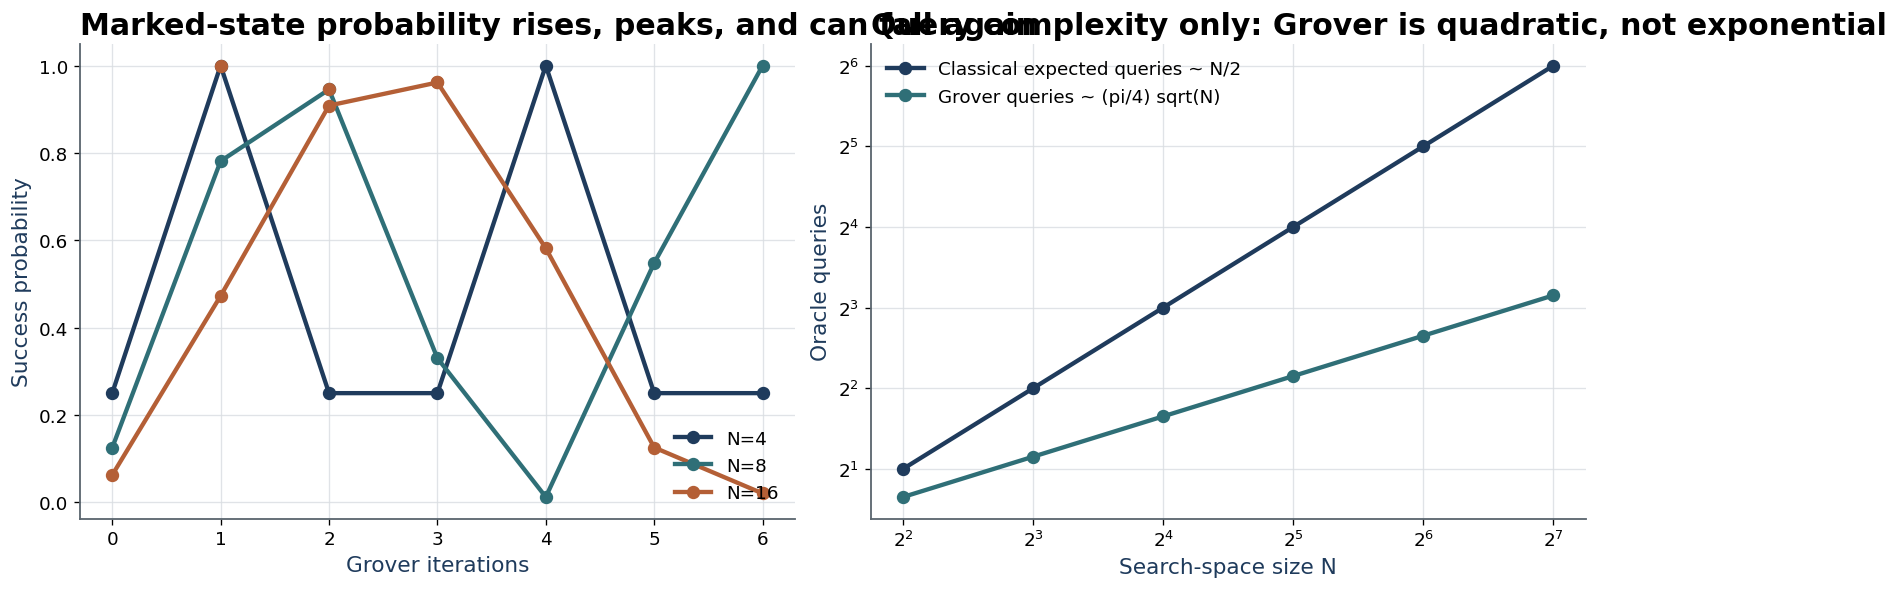

In [36]:
grover_iteration_values = np.arange(0, 7)
search_sizes = np.array([4, 8, 16, 32, 64, 128])

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), constrained_layout=True)

for total_states in [4, 8, 16]:
    probabilities = [grover_success_probability(total_states, iteration) for iteration in grover_iteration_values]
    axes[0].plot(grover_iteration_values, probabilities, marker='o', label=f'N={total_states}')
    theta = np.arcsin(np.sqrt(1 / total_states))
    near_optimal = int(np.round(np.pi / (4 * theta) - 0.5))
    axes[0].scatter([near_optimal], [grover_success_probability(total_states, near_optimal)], color=COLORS['rust'], zorder=5)

axes[0].set_title('Marked-state probability rises, peaks, and can fall again', loc='left')
axes[0].set_xlabel('Grover iterations')
axes[0].set_ylabel('Success probability')
axes[0].legend(loc='lower right')

axes[1].plot(search_sizes, search_sizes / 2, marker='o', label='Classical expected queries ~ N/2')
axes[1].plot(search_sizes, (np.pi / 4) * np.sqrt(search_sizes), marker='o', label='Grover queries ~ (pi/4) sqrt(N)')
axes[1].set_title('Query complexity only: Grover is quadratic, not exponential', loc='left')
axes[1].set_xlabel('Search-space size N')
axes[1].set_ylabel('Oracle queries')
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log', base=2)
axes[1].legend(loc='upper left')

plt.show()


The right-hand plot is deliberately labeled as **query complexity only**. That is the clean theoretical comparison for unstructured search:
- classical search needs on the order of `N` oracle checks,
- Grover needs on the order of `\sqrt{N}` oracle checks.

That is a genuine speedup, but it is only **quadratic**. It does not automatically settle the end-to-end cost of building the oracle, loading the candidate space, or interpreting the answer.


In [37]:
display_wrapped(Markdown(markdown_box(
    'Grover is not an exponential speedup for generic search. It is a quadratic query advantage, and the oracle still has to encode which basis states count as good.',
    title='Common Misconception'
)))


> **Common Misconception:**
> Grover is not an exponential speedup for generic search. It is a quadratic query advantage, and the oracle still has to encode which basis states count as good.

In [38]:
display_wrapped(Markdown(markdown_box(
    'A Grover iteration has two jobs: the oracle phase-marks good states, and diffusion reflects amplitudes about their mean. Repeating that pair rotates probability mass toward the marked subspace until the circuit gets close to optimal, and then past it if you keep going.',
    title='Takeaway'
)))


> **Takeaway:**
> A Grover iteration has two jobs: the oracle phase-marks good states, and diffusion reflects amplitudes about their mean. Repeating that pair rotates probability mass toward the marked subspace until the circuit gets close to optimal, and then past it if you keep going.

In [39]:
display_wrapped(Markdown(instructor_prompt(
    'Why is it pedagogically useful to separate "the oracle marks" from "diffusion amplifies" instead of treating Grover as one mysterious black-box iteration?'
)))


> **Instructor Prompt:**
> Why is it pedagogically useful to separate "the oracle marks" from "diffusion amplifies" instead of treating Grover as one mysterious black-box iteration?

## 7. Grover in Qiskit

**Concept question:** What do the Grover oracle, diffusion operator, and repeated iterations look like as inspectable Qiskit circuits and state changes?


For the implementation examples below, we stay with very small search spaces so the state changes remain visible. The oracles are simple marked-state phase oracles, not hidden library abstractions. That keeps the connection to the earlier oracle discussion explicit: the circuit knows how to act only because we specify which computational-basis label is "good."


In [40]:
def grover_phase_oracle(marked_label, *, name='S_f'):
    n = len(marked_label)
    oracle = QuantumCircuit(n, name=name)
    zero_qubits = [qubit for qubit, bit in enumerate(reversed(marked_label)) if bit == '0']
    for qubit in zero_qubits:
        oracle.x(qubit)
    if n == 1:
        oracle.z(0)
    else:
        oracle.h(n - 1)
        oracle.mcx(list(range(n - 1)), n - 1)
        oracle.h(n - 1)
    for qubit in zero_qubits:
        oracle.x(qubit)
    return oracle


def grover_diffusion(n, *, name='D'):
    diffusion = QuantumCircuit(n, name=name)
    diffusion.h(range(n))
    diffusion.x(range(n))
    if n == 1:
        diffusion.z(0)
    else:
        diffusion.h(n - 1)
        diffusion.mcx(list(range(n - 1)), n - 1)
        diffusion.h(n - 1)
    diffusion.x(range(n))
    diffusion.h(range(n))
    return diffusion


def build_grover_circuit(marked_label, iterations, *, measure=True):
    n = len(marked_label)
    oracle = grover_phase_oracle(marked_label)
    diffusion = grover_diffusion(n)
    circuit = QuantumCircuit(n, n) if measure else QuantumCircuit(n)
    circuit.h(range(n))
    for _ in range(iterations):
        circuit.append(oracle.to_gate(), range(n))
        circuit.append(diffusion.to_gate(), range(n))
    if measure:
        circuit.measure(range(n), range(n))
    return circuit, oracle, diffusion


def grover_stage_circuits(marked_label):
    n = len(marked_label)
    oracle = grover_phase_oracle(marked_label)
    diffusion = grover_diffusion(n)

    uniform = QuantumCircuit(n)
    uniform.h(range(n))

    after_oracle = uniform.copy()
    after_oracle.append(oracle.to_gate(), range(n))

    after_diffusion = after_oracle.copy()
    after_diffusion.append(diffusion.to_gate(), range(n))
    return uniform, after_oracle, after_diffusion, oracle, diffusion


def signed_amplitudes_from_statevector(circuit):
    state = Statevector.from_instruction(circuit)
    labels = bitstrings(circuit.num_qubits)
    amplitudes = state.to_dict()
    ordered = np.array([float(np.real(amplitudes.get(label, 0.0))) for label in labels])
    return labels, ordered


def grover_exact_probabilities(marked_label, iterations):
    circuit, _, _ = build_grover_circuit(marked_label, iterations, measure=False)
    state = Statevector.from_instruction(circuit)
    labels = bitstrings(len(marked_label))
    probabilities = state.probabilities_dict(qargs=list(range(len(marked_label))))
    return {label: float(probabilities.get(label, 0.0)) for label in labels}


def sample_grover_counts(marked_label, iterations, *, shots=1024, seed=7):
    circuit, _, _ = build_grover_circuit(marked_label, iterations, measure=False)
    state = Statevector.from_instruction(circuit)
    np.random.seed(seed)
    sampled = state.sample_counts(shots=shots, qargs=list(range(len(marked_label))))
    labels = bitstrings(len(marked_label))
    return {label: int(sampled.get(label, 0)) for label in labels}


In [41]:
grover_examples_df = pd.DataFrame(
    {
        'Example': ['2-qubit search', '3-qubit search'],
        'Marked state': ['11', '101'],
        'Search-space size N': [4, 8],
        'Near-optimal Grover iterations': [1, 2],
    }
)

display_wrapped(grover_examples_df)


,Example,Marked state,Search-space size N,Near-optimal Grover iterations
0,2-qubit search,11,4,1
1,3-qubit search,101,8,2


**2-qubit marked-state oracle**

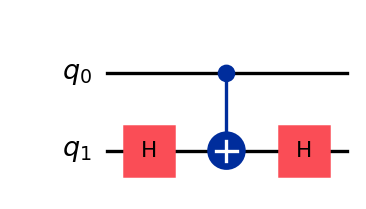

**2-qubit diffusion operator**

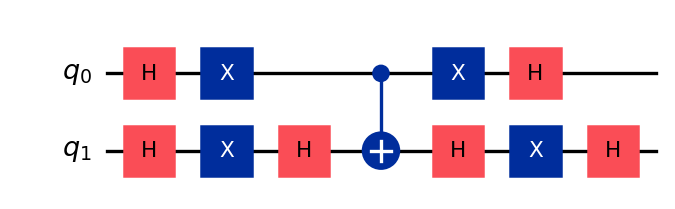

In [42]:
two_qubit_marked = '11'
_, _, _, two_qubit_oracle, two_qubit_diffusion = grover_stage_circuits(two_qubit_marked)

display(Markdown('**2-qubit marked-state oracle**'))
display(two_qubit_oracle.draw('mpl'))
display(Markdown('**2-qubit diffusion operator**'))
display(two_qubit_diffusion.draw('mpl'))


The two circuit blocks have distinct jobs.

The **phase oracle** marks only the chosen computational-basis label. The **diffusion operator** does not know which label was good; it applies the same reflection-about-the-mean transformation to all amplitudes. Grover works because those two reflections are aligned to push weight toward the marked state.


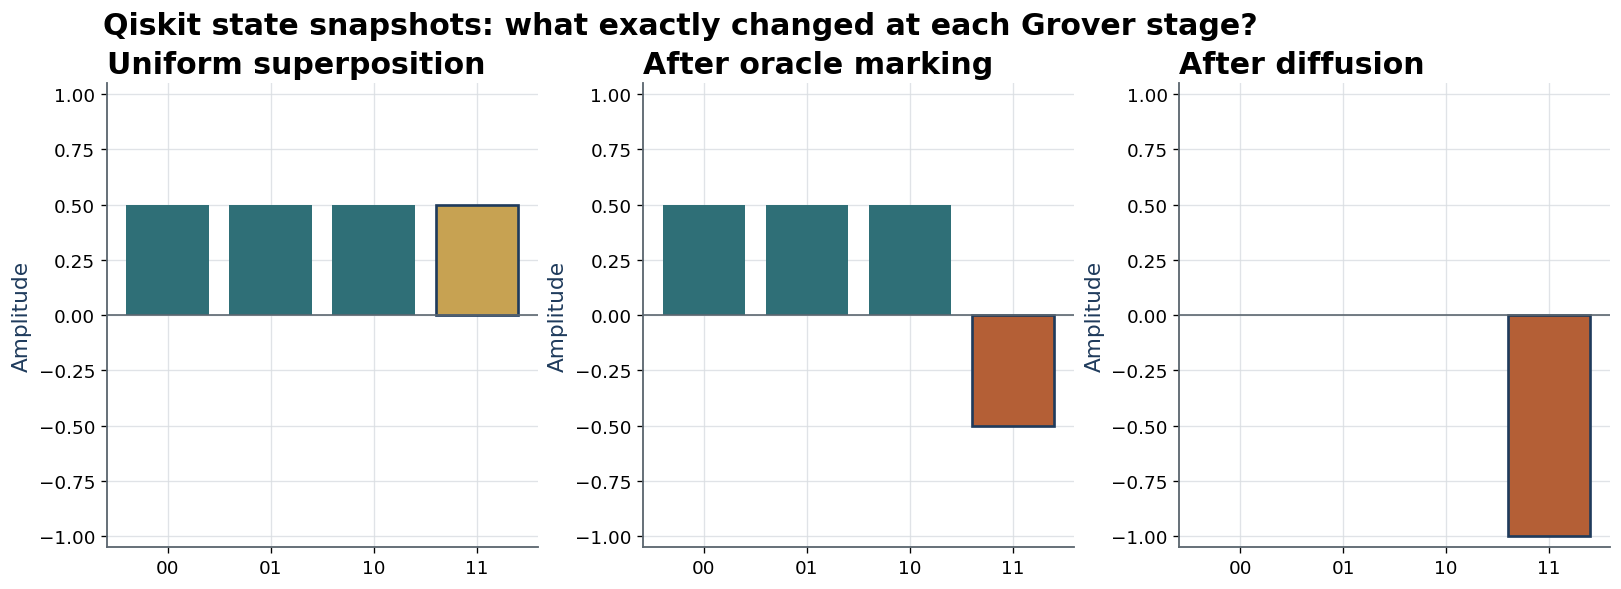

In [43]:
uniform_circuit, after_oracle_circuit, after_diffusion_circuit, _, _ = grover_stage_circuits(two_qubit_marked)
labels, uniform_amplitudes = signed_amplitudes_from_statevector(uniform_circuit)
_, oracle_amplitudes = signed_amplitudes_from_statevector(after_oracle_circuit)
_, diffusion_amplitudes = signed_amplitudes_from_statevector(after_diffusion_circuit)

plot_signed_amplitudes(
    labels,
    [uniform_amplitudes, oracle_amplitudes, diffusion_amplitudes],
    ['Uniform superposition', 'After oracle marking', 'After diffusion'],
    marked_labels={two_qubit_marked},
    title='Qiskit state snapshots: what exactly changed at each Grover stage?'
)
plt.show()


**2-qubit Grover circuit with 1 iteration**

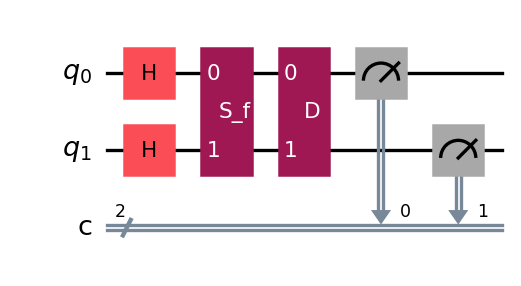

**3-qubit Grover circuit with 2 iterations**

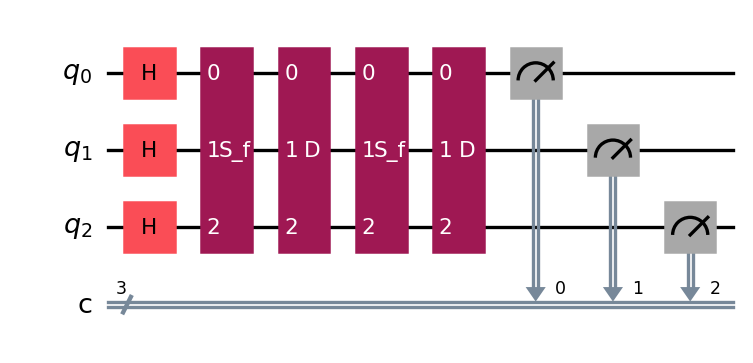

In [44]:
three_qubit_marked = '101'
grover_circuit_two, _, _ = build_grover_circuit(two_qubit_marked, iterations=1)
grover_circuit_three, _, _ = build_grover_circuit(three_qubit_marked, iterations=2)

display(Markdown('**2-qubit Grover circuit with 1 iteration**'))
display(grover_circuit_two.draw('mpl'))
display(Markdown('**3-qubit Grover circuit with 2 iterations**'))
display(grover_circuit_three.draw('mpl'))


,Iteration label,Exact P(marked),Most likely sampled output
0,0 iterations (too few),0.125,100
1,1 iteration,0.781,101
2,2 iterations (near-optimal),0.945,101
3,3 iterations (already overshooting),0.33,101


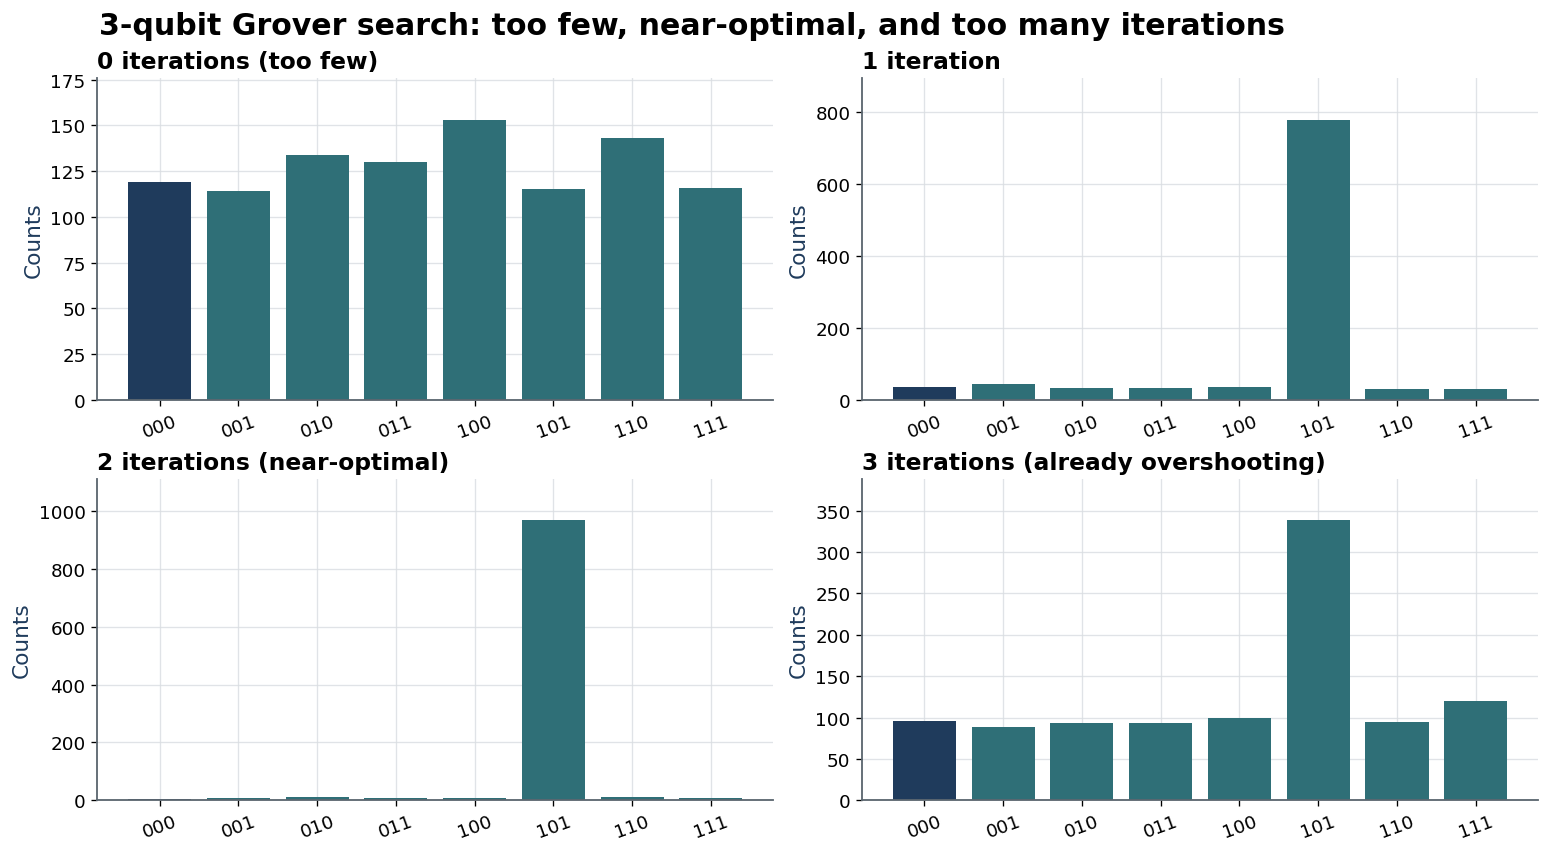

In [45]:
iteration_labels = {
    0: '0 iterations (too few)',
    1: '1 iteration',
    2: '2 iterations (near-optimal)',
    3: '3 iterations (already overshooting)',
}
counts_by_iteration = {}
probability_rows = []
for iteration, label in iteration_labels.items():
    exact_probabilities = grover_exact_probabilities(three_qubit_marked, iteration)
    sampled_counts = sample_grover_counts(three_qubit_marked, iteration, shots=1024, seed=7 + iteration)
    counts_by_iteration[label] = sampled_counts
    probability_rows.append(
        {
            'Iteration label': label,
            'Exact P(marked)': exact_probabilities[three_qubit_marked],
            'Most likely sampled output': max(sampled_counts, key=sampled_counts.get),
        }
    )

probability_progress_df = pd.DataFrame(probability_rows)
display_wrapped(probability_progress_df)
plot_counts_grid(
    counts_by_iteration,
    title='3-qubit Grover search: too few, near-optimal, and too many iterations',
)
plt.show()


The 3-qubit comparison makes the iteration-count story concrete.

With **too few** iterations, the marked state has not been amplified enough. With a **near-optimal** count, the probability of the marked label is high. With **too many** iterations, the state rotates past the good direction and the marked probability drops again.

That is why Grover is not simply "repeat until better." The oracle and diffusion together create a rotation, and rotations can overshoot.


In [46]:
display_wrapped(Markdown(markdown_box(
    'In Grover, the oracle contributes only a phase mark. Diffusion turns that hidden mark into larger amplitude, and repeated Grover iterations can help or hurt depending on how far the state has already rotated toward the marked subspace.',
    title='Takeaway'
)))


> **Takeaway:**
> In Grover, the oracle contributes only a phase mark. Diffusion turns that hidden mark into larger amplitude, and repeated Grover iterations can help or hurt depending on how far the state has already rotated toward the marked subspace.

In [47]:
display_wrapped(Markdown(instructor_prompt(
    "Why does the diffusion operator need the oracle's phase mark first? What would diffusion do to the uniform state if no relative phase difference had been introduced?"
)))


> **Instructor Prompt:**
> Why does the diffusion operator need the oracle's phase mark first? What would diffusion do to the uniform state if no relative phase difference had been introduced?